In [1]:
import pdb
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.pylab as pylab
import cartopy
import cartopy.crs as ccrs
import pickle as pkl
import glob
from metpy import calc
from metpy.units import units
import matplotlib.patches as patches
from scipy import stats

from shared.paths import load_paths
paths = load_paths()

pylab.rcParams['figure.figsize'] = (50., 50.)
%matplotlib inline

In [10]:
paths.cp4_tables

'/gws/ssde/j25b/lmcs/cklein/CP_models/MCS_files/WAf/moved_fromCEH/tables'

In [3]:
def calc_div(da):
    u = units.Quantity(da['u_srfc'].values, 'm/s')
    v = units.Quantity(da['v_srfc'].values, 'm/s')
    
    dx = units.Quantity(4400, 'm')
    div = calc.divergence(u,v, dx=dx, dy=dx)
    # vort = calc.shearing_deformation(u,v, dx, dx)
    da_div = da['sh'].copy(deep=True)
    da_div.values = div
    
    return da_div

In [4]:
def calc_div_mid(da):
    u = units.Quantity(da['u_mid'].values, 'm/s')
    v = units.Quantity(da['v_mid'].values, 'm/s')
    
    dx = units.Quantity(4400, 'm')
    div = calc.divergence(u,v, dx=dx, dy=dx)
    # vort = calc.shearing_deformation(u,v, dx, dx)
    da_div = da['sh'].copy(deep=True)
    da_div.values = div
    
    return da_div

In [19]:
def calc_theta(da):    
    p = units.Quantity(925, 'hPa')
    t = units.Quantity(da['t_srfc'].values+273.15, 'K')
    q = units.Quantity(da['q_srfc'].values/1000, 'kg/kg')
    
    p_up = units.Quantity(650, 'hPa')
    t_up = units.Quantity(da['t_mid'].values+273.15, 'K')
    
    thetaes_up = np.asarray(calc.saturation_equivalent_potential_temperature(p_up, t_up).magnitude)
    
    dew = calc.dewpoint_from_specific_humidity(p,t,q)
    thetae_down = np.asarray(calc.equivalent_potential_temperature(p, t, dew).magnitude)
     
    thetae = thetae_down #-thetaes_up 
    
    da_theta = da['sh'].copy(deep=True)
    da_theta.values = thetae
    
  #  ipdb.set_trace()
    
    return da_theta

In [20]:
cp4_path = paths.cp4_tables#'/gws/nopw/j04/lmcs/cklein/CP_models/MCS_files/WAf/CP4_box_JASMIN/mean3h_v2/' #instantaneous_18h_v1/'

In [23]:
cp4_path

'/gws/ssde/j25b/lmcs/cklein/CP_models/MCS_files/WAf/moved_fromCEH/tables'

In [12]:
da_hist_anom = xr.open_mfdataset(cp4_path + '/anomMean_*_hist.nc', concat_dim='month', combine="nested").load().mean('month')
da_fut_anom = xr.open_mfdataset(cp4_path + '/anomMean_*_fut.nc', concat_dim='month', combine="nested").load().mean('month')

In [13]:
da_hist = xr.open_mfdataset(cp4_path + '/mean_*_hist.nc', concat_dim='month', combine="nested").load().mean('month')
da_fut = xr.open_mfdataset(cp4_path + '/mean_*_fut.nc', concat_dim='month', combine="nested").load().mean('month')

In [14]:
clim_hist = da_hist-da_hist_anom
clim_fut = da_fut-da_fut_anom

In [22]:
list(da_fut.keys())

['lw_out_PBLtop',
 'lsRain',
 'shear',
 'u_mid',
 'u_srfc',
 'v_mid',
 'v_srfc',
 'q_mid',
 't_mid',
 't_srfc',
 'q_srfc',
 'geoH_srfc',
 'tcwv',
 'sh',
 'lh',
 't2',
 'q2',
 'lsRain_noon',
 'lwout_noon']

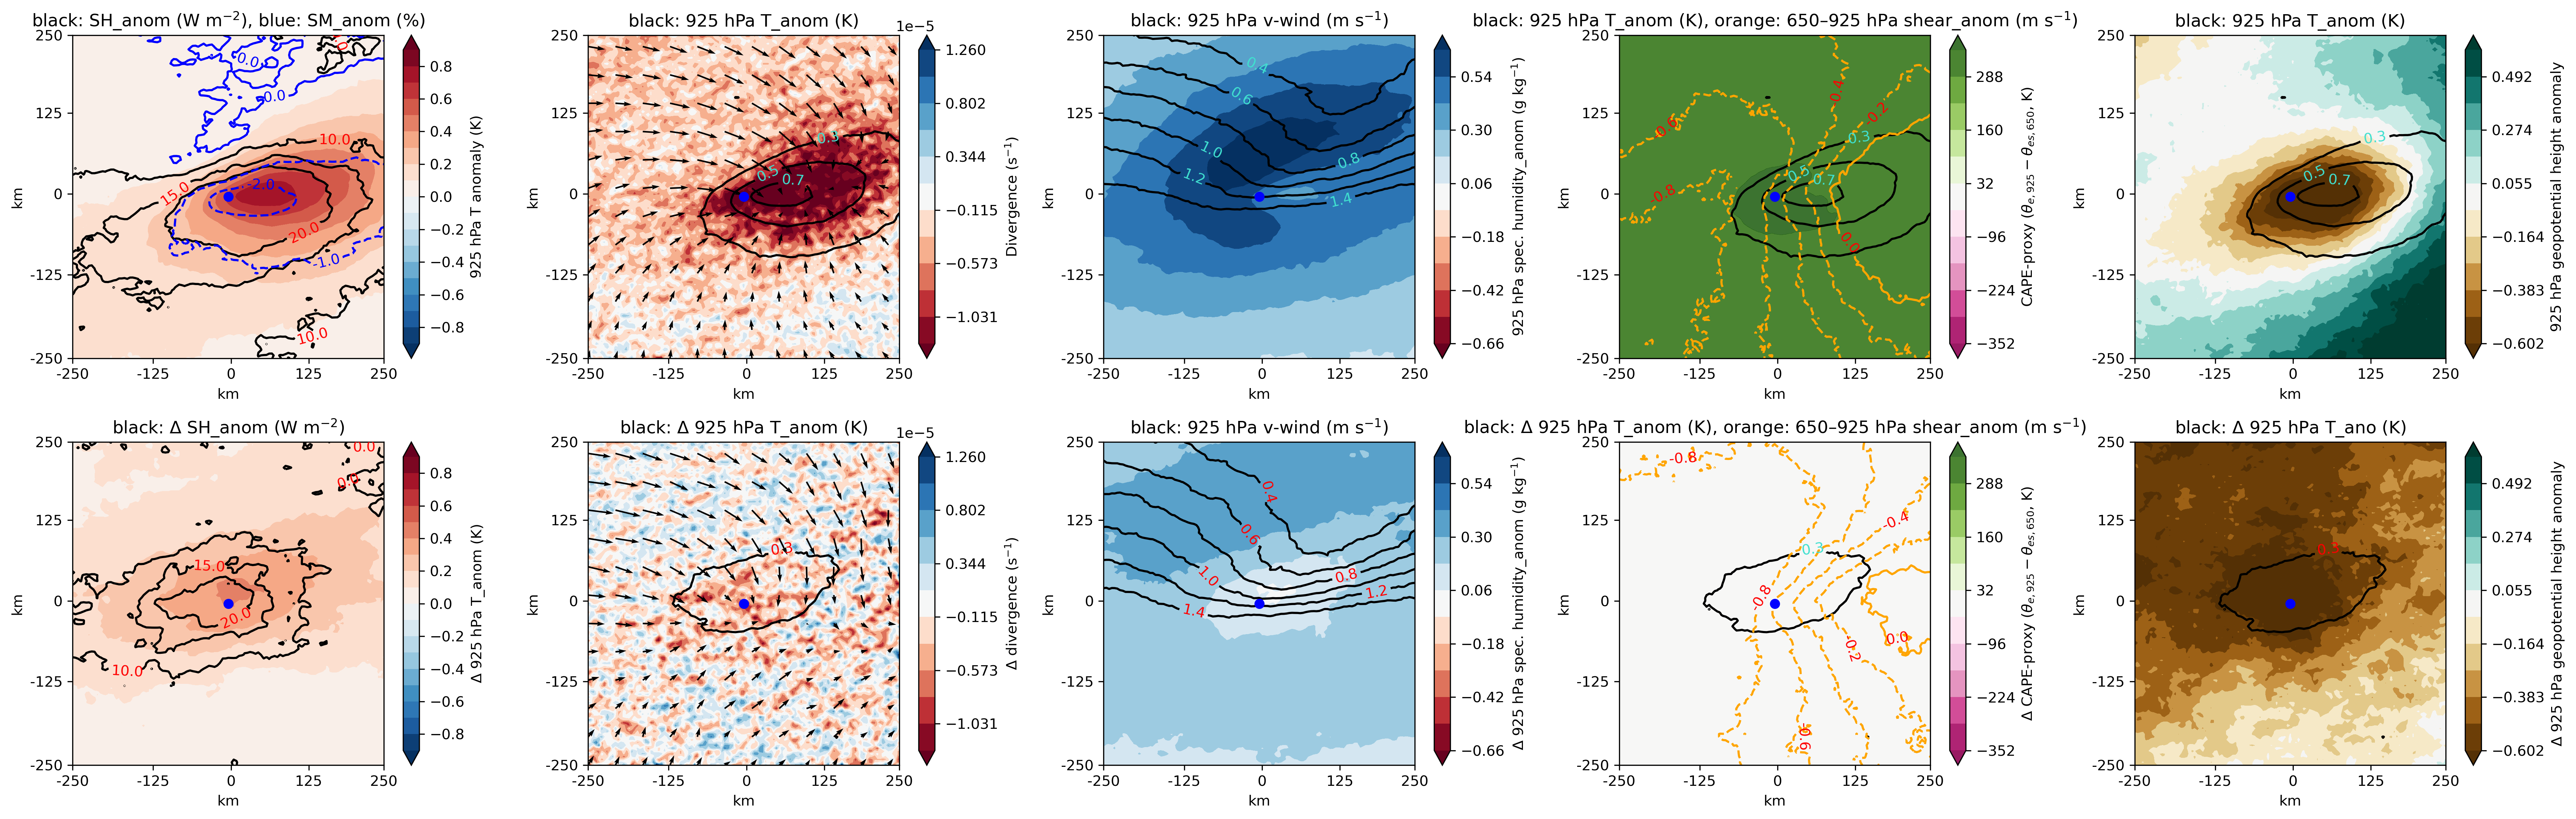

In [21]:
fig = plt.figure(figsize=(25, 8), dpi=300)

extent = 57
ticks = np.array([0, 58 - 57/2, 58, 58 + 57/2, 114])
tick_labels = [-250, -125, 0, 125, 250]

temp_levels = [-0.9, -0.7, -0.5, -0.3, 0, 0.3, 0.5, 0.7, 0.9]
sh_levels = [-20, -15, -10, 0, 10, 15, 20]
sm_levels = [-2, -1, 0, 1, 2]
v_levels = [-1.4, -1.2, -1, -0.8, -0.6, -0.4, 0, 0.4, 0.6, 0.8, 1, 1.2, 1.4]
shear_levels = [-0.8, -0.6, -0.4, -0.2, 0]


def get_symmetric_levels(data, n=12, percentiles=(5, 95)):
    thresh = np.nanmax(np.abs(np.nanpercentile(np.asarray(data), percentiles)))
    return np.linspace(-thresh, thresh, n)


def format_axis(ax):
    ax.plot(extent, extent, 'bo')
    ax.set(xlabel='km', ylabel='km', xticks=ticks, yticks=ticks)
    ax.set_xticklabels(tick_labels)
    ax.set_yticklabels(tick_labels)


def add_contours(ax, data, levels, color='k', label_color=None, linewidth=1.5):
    cs = ax.contour(data, colors=color, levels=levels, linewidths=linewidth)
    ax.clabel(cs, inline=True, fontsize=10, fmt='%1.1f', colors=label_color or color)
    return cs


def add_quiver(ax, u, v, step=10):
    x = np.arange(u.shape[1])[::step]
    y = np.arange(u.shape[0])[::step]
    ax.quiver(x, y, np.asarray(u)[::step, ::step], np.asarray(v)[::step, ::step])


# Precalculate repeated quantities
div_hist = calc_div(da_hist)
div_fut = calc_div(da_fut)

theta_hist = calc_theta(da_hist)
theta_fut = calc_theta(da_fut)

div_levels = get_symmetric_levels(div_hist)
theta_levels = get_symmetric_levels(theta_hist)
q_levels = get_symmetric_levels(da_hist_anom['q_srfc'])
geoh_levels = get_symmetric_levels(da_hist_anom['geoH_srfc'])


# ================================================================
# 1. Historical temperature, sensible heat and soil moisture
# ================================================================

ax = fig.add_subplot(2, 5, 1)

ano = da_hist_anom['t_srfc']
cont = da_hist_anom['sh']
cont2 = da_hist_anom['SM']

cf = ax.contourf(ano, cmap='RdBu_r', extend='both', levels=np.arange(-0.9, 0.91, 0.1))
fig.colorbar(cf, ax=ax, label='925 hPa T anomaly (K)')
ax.set_title(r'black: SH_anom (W m$^{-2}$), blue: SM_anom (%)')

add_contours(ax, cont, sh_levels, color='k', label_color='r')
add_contours(ax, cont2, sm_levels, color='blue', label_color='blue')
format_axis(ax)


# ================================================================
# 2. Historical divergence
# ================================================================

ax = fig.add_subplot(2, 5, 2)

cf = ax.contourf(div_hist, cmap='RdBu', extend='both', levels=div_levels)
fig.colorbar(cf, ax=ax, label=r'Divergence (s$^{-1}$)')
ax.set_title('black: 925 hPa T_anom (K)')

add_contours(ax, da_hist_anom['t_srfc'], temp_levels, color='k', label_color='turquoise')
add_quiver(ax, da_hist_anom['u_srfc'], da_hist_anom['v_srfc'])
format_axis(ax)


# ================================================================
# 3. Historical humidity and v wind
# ================================================================

ax = fig.add_subplot(2, 5, 3)

ano = da_hist_anom['q_srfc']
cont = da_hist['v_srfc']

cf = ax.contourf(ano, cmap='RdBu', extend='both', levels=q_levels)
fig.colorbar(cf, ax=ax, label=r'925 hPa spec. humidity_anom (g kg$^{-1}$)')
ax.set_title(r'black: 925 hPa v-wind (m s$^{-1}$)')

add_contours(ax, cont, v_levels, color='k', label_color='turquoise')
format_axis(ax)


# ================================================================
# 4. Historical CAPE proxy
# ================================================================

ax = fig.add_subplot(2, 5, 4)

cf = ax.contourf(theta_hist, cmap='PiYG', extend='both', levels=theta_levels, alpha=0.9)
fig.colorbar(cf, ax=ax, label=r'CAPE-proxy ($\theta_{e,925}-\theta_{es,650}$, K)')
ax.set_title(r'black: 925 hPa T_anom (K), orange: 650–925 hPa shear_anom (m s$^{-1}$)')

add_contours(ax, da_hist_anom['t_srfc'], temp_levels, color='k', label_color='turquoise')
add_contours(ax, da_hist_anom['shear'], shear_levels, color='orange', label_color='red')
format_axis(ax)


# ================================================================
# 5. Historical geopotential height
# ================================================================

ax = fig.add_subplot(2, 5, 5)

ano = da_hist_anom['geoH_srfc']

cf = ax.contourf(ano, cmap='BrBG', extend='both', levels=geoh_levels)
fig.colorbar(cf, ax=ax, label='925 hPa geopotential height anomaly')
ax.set_title('black: 925 hPa T_anom (K)')

add_contours(ax, da_hist_anom['t_srfc'], temp_levels, color='k', label_color='turquoise')
format_axis(ax)


# ================================================================
# 6. Future minus historical temperature and sensible heat
# ================================================================

ax = fig.add_subplot(2, 5, 6)

ano = da_fut_anom['t_srfc'] - da_hist_anom['t_srfc']
cont = da_fut_anom['sh'] - da_hist_anom['sh']

cf = ax.contourf(ano, cmap='RdBu_r', extend='both', levels=np.arange(-0.9, 0.91, 0.1))
fig.colorbar(cf, ax=ax, label=r'$\Delta$ 925 hPa T_anom (K)')
ax.set_title(r'black: $\Delta$ SH_anom (W m$^{-2}$)')

add_contours(ax, cont, sh_levels, color='k', label_color='r')
format_axis(ax)


# ================================================================
# 7. Future minus historical divergence
# ================================================================

ax = fig.add_subplot(2, 5, 7)

ano = div_fut - div_hist
cont = da_fut_anom['t_srfc'] - da_hist_anom['t_srfc']

cf = ax.contourf(ano, cmap='RdBu', extend='both', levels=div_levels)
fig.colorbar(cf, ax=ax, label=r'$\Delta$ divergence (s$^{-1}$)')
ax.set_title(r'black: $\Delta$ 925 hPa T_anom (K)')

add_contours(ax, cont, temp_levels, color='k', label_color='r')

u_diff = da_fut_anom['u_srfc'] - da_hist_anom['u_srfc']
v_diff = da_fut_anom['v_srfc'] - da_hist_anom['v_srfc']
add_quiver(ax, u_diff, v_diff)

format_axis(ax)


# ================================================================
# 8. Future minus historical humidity
# ================================================================

ax = fig.add_subplot(2, 5, 8)

ano = da_fut_anom['q_srfc'] - da_hist_anom['q_srfc']
cont = da_fut['v_srfc']

cf = ax.contourf(ano, cmap='RdBu', extend='both', levels=q_levels)
fig.colorbar(cf, ax=ax, label=r'$\Delta$ 925 hPa spec. humidity_anom (g kg$^{-1}$)')
ax.set_title(r'black: 925 hPa v-wind (m s$^{-1}$)')

add_contours(ax, cont, v_levels, color='k', label_color='r')
format_axis(ax)


# ================================================================
# 9. Future minus historical CAPE proxy
# ================================================================

ax = fig.add_subplot(2, 5, 9)

ano = theta_fut - theta_hist
cont = da_fut_anom['t_srfc'] - da_hist_anom['t_srfc']
cont2 = da_fut_anom['shear']

cf = ax.contourf(ano, cmap='PiYG', extend='both', levels=theta_levels, alpha=0.9)
fig.colorbar(cf, ax=ax, label=r'$\Delta$ CAPE-proxy ($\theta_{e,925}-\theta_{es,650}$, K)')
ax.set_title(r'black: $\Delta$ 925 hPa T_anom (K), orange: 650–925 hPa shear_anom (m s$^{-1}$)')

add_contours(ax, cont, temp_levels, color='k', label_color='turquoise')
add_contours(ax, cont2, shear_levels, color='orange', label_color='red')
format_axis(ax)


# ================================================================
# 10. Future minus historical geopotential height
# ================================================================

ax = fig.add_subplot(2, 5, 10)

ano = da_fut_anom['geoH_srfc'] - da_hist_anom['geoH_srfc']
cont = da_fut_anom['t_srfc'] - da_hist_anom['t_srfc']

cf = ax.contourf(ano, cmap='BrBG', extend='both', levels=geoh_levels)
fig.colorbar(cf, ax=ax, label=r'$\Delta$ 925 hPa geopotential height anomaly')
ax.set_title(r'black: $\Delta$ 925 hPa T_ano (K)')

add_contours(ax, cont, temp_levels, color='k', label_color='r')
format_axis(ax)


fig.tight_layout()

# fig.savefig(cnst.network_data + 'figs/LMCS/CP4_PNASstudy/composites_hist_fut_tcwv.jpg',
#             dpi=300, bbox_inches='tight')

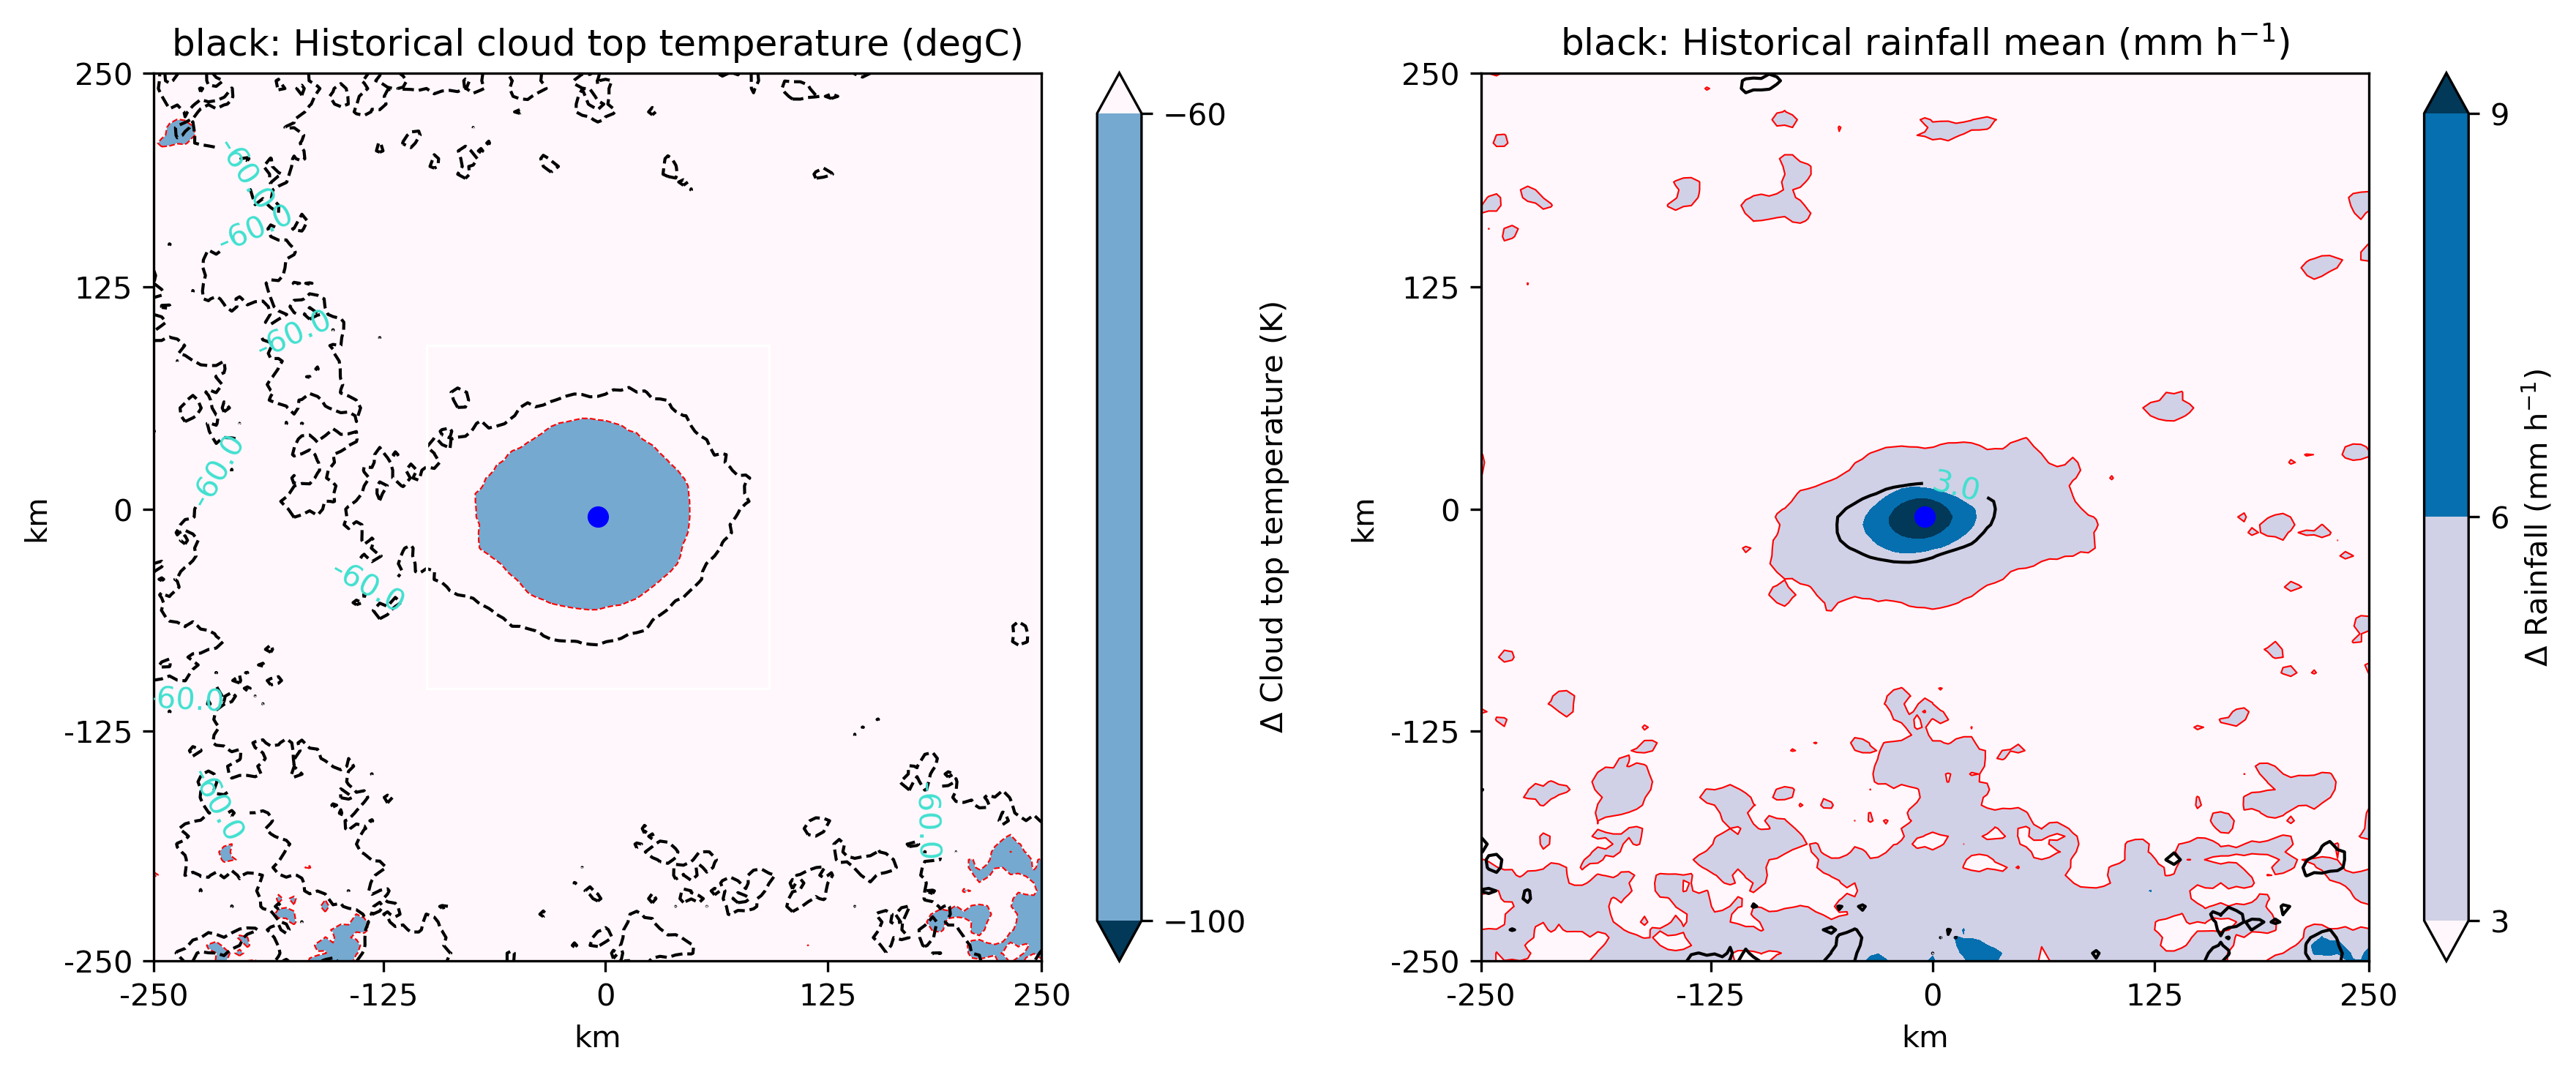

In [26]:
f = plt.figure(figsize=(12,5), dpi=300)
mname = 'node'
extent = 57 #* 4.4

ticks = np.array([0,58-57/2,58,58+57/2,114])
#labels = np.rint([-57*4.4,-57/2*4.4,0,57/2*4.4, 57*4.4])
labels = [-250,-125,0,125,250]
box = [57-22, 57+22, 57-22, 57+22]

ax = f.add_subplot(1,2,1)

ano =da_fut['lw_out_PBLtop']#-da_hist['lw_out_PBLtop']
cont = da_hist['lw_out_PBLtop']

thresh = np.max(np.abs(np.percentile(ano, [5, 95])))

plt.contourf(ano, cmap='PuBu_r', extend='both', levels=[-100,-60]) #levels=np.linspace(thresh * -1, thresh, 10)
plt.colorbar(label=r'$\Delta$ Cloud top temperature (K)')
cm = ax.contour(ano, colors='r', levels=[-100,-60], linewidths=0.5)
plt.title('black: Historical cloud top temperature (degC)')
cm = ax.contour(cont, colors='k', levels=[-100,-60], linewidths=1)
ax.clabel(cm, inline=True, fontsize=10, fmt='%1.1f', colors='turquoise')
rect2 = patches.Rectangle((box[0],box[2]),box[1]-box[0],box[3]-box[2],linewidth=0.8,edgecolor='w',facecolor='none', zorder=99)
ax.add_patch(rect2)

plt.plot(extent, extent, 'bo')
ax.set_xlabel('km')
ax.set_ylabel('km')
ax.set_xticks(ticks)
ax.set_xticklabels(labels)
ax.set_yticks(ticks)
ax.set_yticklabels(labels)

ax = f.add_subplot(1,2,2)
ano =da_fut['lsRain']#-da_hist['lsRain'])
cont = da_hist['lsRain']

thresh = np.max(np.abs(np.percentile(ano, [5, 95])))

plt.contourf(ano, cmap='PuBu', extend='both', levels=[3,6,9])
plt.colorbar(label=r'$\Delta$ Rainfall (mm h$^{-1}$)')
plt.contour(ano, colors='red', levels=[-5,3], linewidths=0.5)#levels=np.linspace(thresh * -1, thresh, 10)

plt.title(r'black: Historical rainfall mean (mm h$^{-1}$)')
cm = ax.contour(cont, colors='k', levels=[-5, 3], linewidths=1)
ax.clabel(cm, inline=True, fontsize=10, fmt='%1.1f', colors='turquoise')

# pv, pw = da_hist_anom['u_srfc'].values, da_hist_anom['v_srfc'].values
# qv = plt.quiver(np.arange(da_hist.longitude.shape[0])[::10], np.arange(da_hist.latitude.shape[0])[::10], pv[::10,::10], pw[::10,::10])

plt.plot(extent, extent, 'bo')
ax.set_xlabel('km')
ax.set_ylabel('km')
ax.set_xticks(ticks)
ax.set_xticklabels(labels)
ax.set_yticks(ticks)
ax.set_yticklabels(labels)

plt.tight_layout()

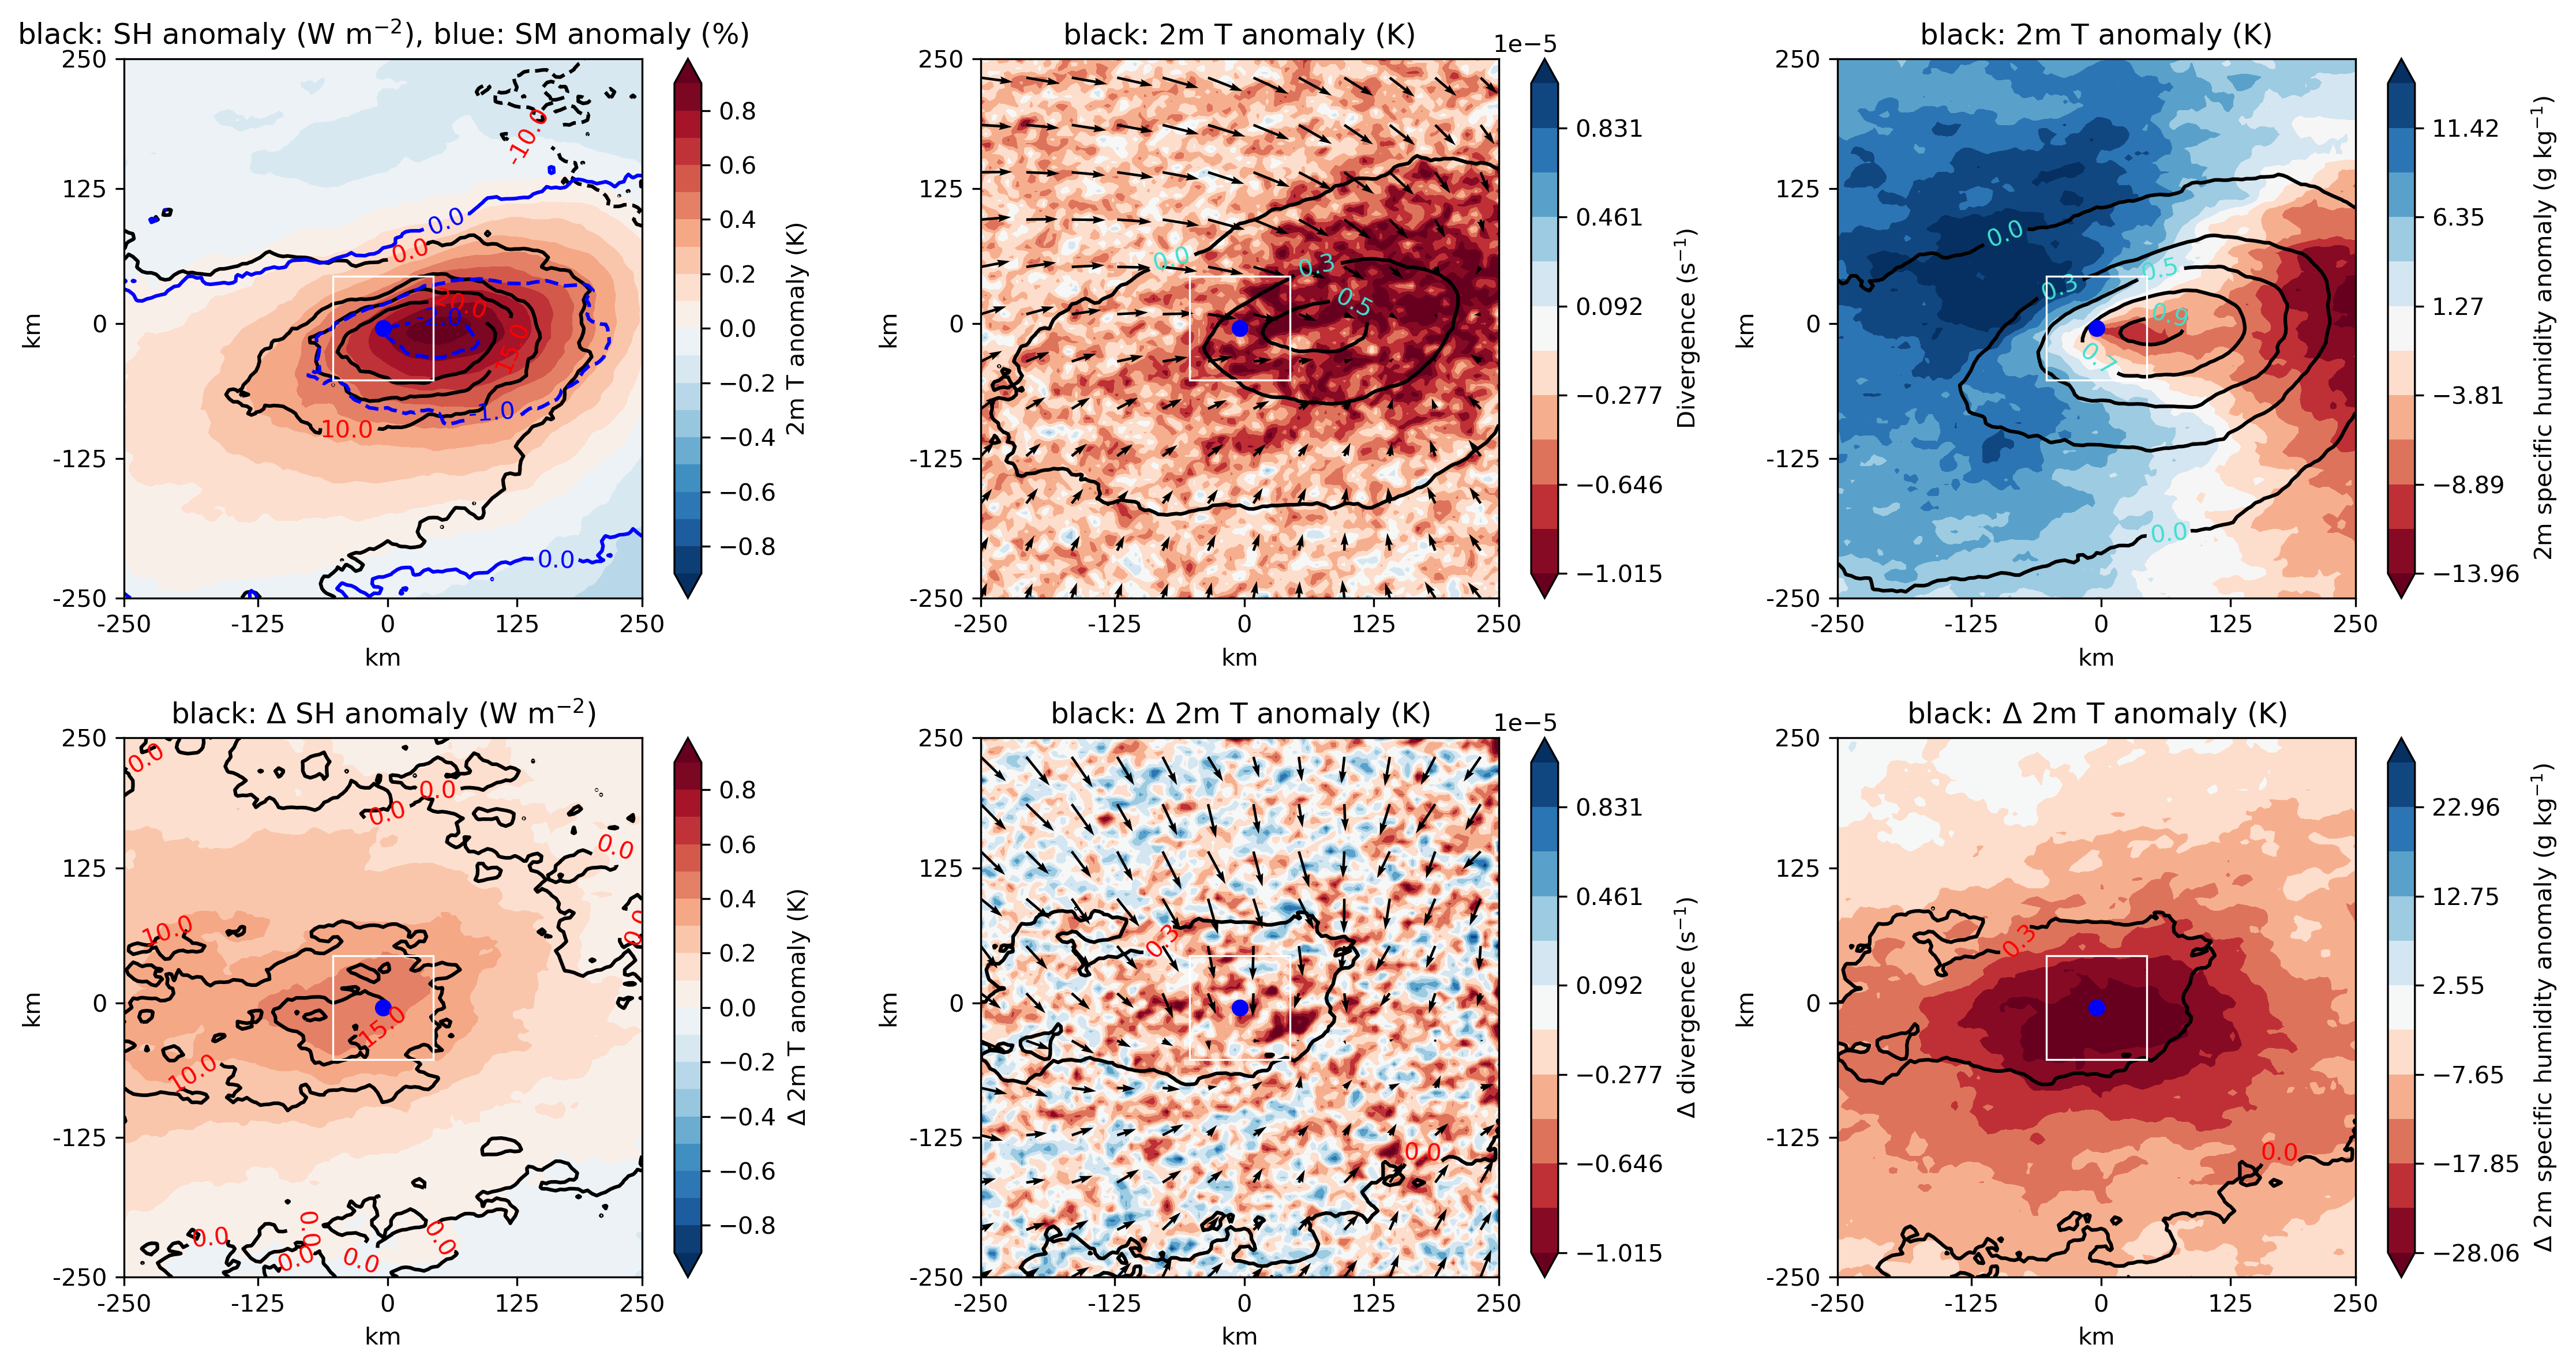

In [44]:
f = plt.figure(figsize=(15,8), dpi=300)
mname = 'node'
extent = 57 #* 4.4

ticks = np.array([0,58-57/2,58,58+57/2,114])
#labels = np.rint([-57*4.4,-57/2*4.4,0,57/2*4.4, 57*4.4])
labels = [-250,-125,0,125,250]
mid=57
dist = 11
box = [mid-dist, mid+dist,mid-dist, mid+dist]

ax = f.add_subplot(2,3,1)

#ano = da_hist_anom['t2']#.mean('cases')
cont =da_hist_anom['sh']
cont2 = da_hist_anom['SM']
ano = da_hist_anom['t2']

thresh = np.max(np.abs(np.percentile(ano, [5, 95])))

plt.contourf(ano, cmap='RdBu_r', extend='both', levels=np.arange(-0.9,0.91,0.1)) #levels=np.linspace(thresh * -1, thresh, 10)
plt.colorbar(label='2m T anomaly (K)')
plt.title(r'black: SH anomaly (W m$^{-2}$), blue: SM anomaly (%)')
cm = ax.contour(cont, colors='k', levels=[-20,-15,-10,0,10,15,20], linewidths=1.5)
ax.clabel(cm, inline=True, fontsize=10, fmt='%1.1f', colors='r')

cm = ax.contour(cont2, colors='blue', levels=[-2,-1,0,1,2], linewidths=1.5)
ax.clabel(cm, inline=True, fontsize=10, fmt='%1.1f', colors='blue')
rect2 = patches.Rectangle((box[0],box[2]),box[1]-box[0],box[3]-box[2],linewidth=0.8,edgecolor='w',facecolor='none', zorder=99)
ax.add_patch(rect2)

plt.plot(extent, extent, 'bo')
ax.set_xlabel('km')
ax.set_ylabel('km')
ax.set_xticks(ticks)
ax.set_xticklabels(labels)
ax.set_yticks(ticks)
ax.set_yticklabels(labels)

ax = f.add_subplot(2,3,2)
ano_div = calc_div(da_hist)
cont = da_hist_anom['t_srfc']

thresh = np.max(np.abs(np.percentile(ano_div, [5, 95])))

plt.contourf(ano_div, cmap='RdBu', extend='both', levels=np.linspace(thresh * -1, thresh, 12)) #levels=np.linspace(thresh * -1, thresh, 10)
plt.colorbar(label='Divergence (s$^{-1}$)')
plt.title(r'black: 2m T anomaly (K)')
cm = ax.contour(cont, colors='k', levels=[-0.9, -0.7,-0.5,-0.3,0,0.3,0.5,0.7,0.9], linewidths=1.5)
ax.clabel(cm, inline=True, fontsize=10, fmt='%1.1f', colors='turquoise')
rect2 = patches.Rectangle((box[0],box[2]),box[1]-box[0],box[3]-box[2],linewidth=0.8,edgecolor='w',facecolor='none', zorder=99)
ax.add_patch(rect2)

pv, pw = da_hist_anom['u_srfc'].values, da_hist_anom['v_srfc'].values
qv = plt.quiver(np.arange(da_hist.longitude.shape[0])[::10], np.arange(da_hist.latitude.shape[0])[::10], pv[::10,::10], pw[::10,::10])

plt.plot(extent, extent, 'bo')
ax.set_xlabel('km')
ax.set_ylabel('km')
ax.set_xticks(ticks)
ax.set_xticklabels(labels)
ax.set_yticks(ticks)
ax.set_yticklabels(labels)


ax = f.add_subplot(2,3,3)
ano = da_hist_anom['lh']
cont = da_hist_anom['t2']

thresh = np.max(np.abs(np.percentile(ano, [5, 95])))

plt.contourf(ano, cmap='RdBu', extend='both', levels=np.linspace(thresh * -1, thresh, 12)) #levels=np.linspace(thresh * -1, thresh, 10)
plt.colorbar(label=r'2m specific humidity anomaly (g kg$^{-1}$)')
plt.title(r'black: 2m T anomaly (K)')
cm = ax.contour(cont, colors='k', levels=[-0.9, -0.7,-0.5,-0.3,0,0.3,0.5,0.7,0.9], linewidths=1.5)
ax.clabel(cm, inline=True, fontsize=10, fmt='%1.1f', colors='turquoise')
rect2 = patches.Rectangle((box[0],box[2]),box[1]-box[0],box[3]-box[2],linewidth=0.8,edgecolor='w',facecolor='none', zorder=99)
ax.add_patch(rect2)


plt.plot(extent, extent, 'bo')
ax.set_xlabel('km')
ax.set_ylabel('km')
ax.set_xticks(ticks)
ax.set_xticklabels(labels)
ax.set_yticks(ticks)
ax.set_yticklabels(labels)



###############################################

ax = f.add_subplot(2,3,4)

#ano = da_hist_anom['t2']#.mean('cases')
cont =da_fut_anom['sh']-da_hist_anom['sh']

ano = da_fut_anom['t2']-da_hist_anom['t2']

thresh = np.max(np.abs(np.percentile(ano, [5, 95])))

plt.contourf(ano, cmap='RdBu_r', extend='both', levels=np.arange(-0.9,0.91,0.1))  #levels=np.linspace(thresh * -1, thresh, 10)
plt.colorbar(label=r'$\Delta$ 2m T anomaly (K)')
plt.title(r'black: $\Delta$ SH anomaly (W m$^{-2}$)')
cm = ax.contour(cont, colors='k', levels=[-20,-15,-10,0, 10,15,20], linewidths=1.5)
ax.clabel(cm, inline=True, fontsize=10, fmt='%1.1f', colors='r')
rect2 = patches.Rectangle((box[0],box[2]),box[1]-box[0],box[3]-box[2],linewidth=0.8,edgecolor='w',facecolor='none', zorder=99)
ax.add_patch(rect2)


plt.plot(extent, extent, 'bo')
ax.set_xlabel('km')
ax.set_ylabel('km')
ax.set_xticks(ticks)
ax.set_xticklabels(labels)
ax.set_yticks(ticks)
ax.set_yticklabels(labels)


ax = f.add_subplot(2,3,5)

ano = calc_div(da_hist)
anofut = calc_div(da_fut)
ano = anofut-ano
cont = da_fut_anom['t2']-da_hist_anom['t2']

thresh = np.max(np.abs(np.percentile(ano_div, [5, 95])))

plt.contourf(ano, cmap='RdBu', extend='both', levels=np.linspace(thresh * -1, thresh, 12)) #levels=np.linspace(thresh * -1, thresh, 10)
plt.colorbar(label=r'$\Delta$ divergence (s$^{-1}$)')
plt.title(r'black: $\Delta$ 2m T anomaly (K)')
cm = ax.contour(cont, colors='k', levels=[-0.9,-0.7,-0.5,-0.3,0,0.3,0.5,0.7,0.9], linewidths=1.5)
ax.clabel(cm, inline=True, fontsize=10, fmt='%1.1f', colors='r')
rect2 = patches.Rectangle((box[0],box[2]),box[1]-box[0],box[3]-box[2],linewidth=0.8,edgecolor='w',facecolor='none', zorder=99)
ax.add_patch(rect2)

pv, pw = da_fut_anom['u_srfc'].values-da_hist_anom['u_srfc'].values, da_fut_anom['v_srfc'].values-da_hist_anom['v_srfc'].values
qv = plt.quiver(np.arange(da_hist.longitude.shape[0])[::10], np.arange(da_hist.latitude.shape[0])[::10], pv[::10,::10], pw[::10,::10])

plt.plot(extent, extent, 'bo')
ax.set_xlabel('km')
ax.set_ylabel('km')
ax.set_xticks(ticks)
ax.set_xticklabels(labels)
ax.set_yticks(ticks)
ax.set_yticklabels(labels)

# ax = f.add_subplot(2,4,8)
# pano = da_hist_anom['q_srfc']
# ano = da_fut_anom['q_srfc']-da_hist_anom['q_srfc']
# cont = da_fut['v_srfc']

# thresh = np.max(np.abs(np.percentile(pano, [5, 95])))

# plt.contourf(ano, cmap='RdBu', extend='both', levels=np.linspace(thresh * -1, thresh, 12)) #levels=np.linspace(thresh * -1, thresh, 10)
# plt.colorbar(label='$\Delta$ 925 hPa spec. q anomaly (g kg$^{-1}$)')
# plt.title('black: 925hPa v-wind (m s$^{-1}$)')
# cm = ax.contour(cont, colors='k', levels=[-1.4,-1.2,-1, -0.8, -0.6,-0.4,0,0.4,0.6,0.8,1,1.2,1.4], linewidths=1.5)
# ax.clabel(cm, inline=True, fontsize=10, fmt='%1.1f', colors='r')

# plt.plot(extent, extent, 'bo')
# ax.set_xlabel('km')
# ax.set_ylabel('km')
# ax.set_xticks(ticks)
# ax.set_xticklabels(labels)
# ax.set_yticks(ticks)
# ax.set_yticklabels(labels)


ax = f.add_subplot(2,3,6)
ano = (da_fut_anom['lh']-da_hist_anom['lh'])#*1000
cont = da_fut_anom['t2']-da_hist_anom['t2']
pano = (da_fut_anom['lh'])

qthresh = np.max(np.abs(np.percentile(pano, [5, 95])))

plt.contourf(ano, cmap='RdBu', extend='both', levels=np.linspace(qthresh * -1, qthresh, 12)) 
plt.colorbar(label=r'$\Delta$ 2m specific humidity anomaly (g kg$^{-1}$)')
plt.title(r'black: $\Delta$ 2m T anomaly (K)')
cm = ax.contour(cont, colors='k', levels=[-0.9, -0.7,-0.5,-0.3,0,0.3,0.5,0.7,0.9], linewidths=1.5)
ax.clabel(cm, inline=True, fontsize=10, fmt='%1.1f', colors='r')
rect2 = patches.Rectangle((box[0],box[2]),box[1]-box[0],box[3]-box[2],linewidth=0.8,edgecolor='w',facecolor='none', zorder=99)
ax.add_patch(rect2)


plt.plot(extent, extent, 'bo')
ax.set_xlabel('km')
ax.set_ylabel('km')
ax.set_xticks(ticks)
ax.set_xticklabels(labels)
ax.set_yticks(ticks)
ax.set_yticklabels(labels)



plt.tight_layout()
#f.savefig(cnst.network_data + 'figs/LMCS/CP4_PNASstudy/composites_hist_fut_paper_fig1_q2.jpg')

In [32]:
cp4_path = paths.cp4_2d

In [35]:
cp4_path

'/gws/ssde/j25b/lmcs/cklein/CP_models/MCS_files/WAf'

In [53]:
da_hist_anom = xr.open_dataset(cp4_path + '/CP4_box_JASMIN/instantaneous_18h_v1/hist_anom_all_18h_2d.nc')
da_fut_anom = xr.open_dataset(cp4_path + '/CP4_box_JASMIN/instantaneous_18h_v1/fut_anom_all_18h_2d.nc')

In [54]:
da_hist = xr.open_dataset(cp4_path + '/CP4_box_JASMIN/instantaneous_18h_v1/hist_mean_all_18h_2d.nc')
da_fut = xr.open_dataset(cp4_path + '/CP4_box_JASMIN/instantaneous_18h_v1/fut_mean_all_18h_2d.nc')

In [55]:
print(list(da_fut_anom.keys()))

['lw_out_PBLtop', 'lsRain', 'tcwv', 'sh', 'lh', 't2', 'q2', 'shear', 'u_mid', 'u_srfc', 'v_mid', 'v_srfc', 'q_mid', 't_mid', 't_srfc', 'q_srfc', 'geoH_srfc', 'lsRain_noon', 'lwout_noon', 'SM']


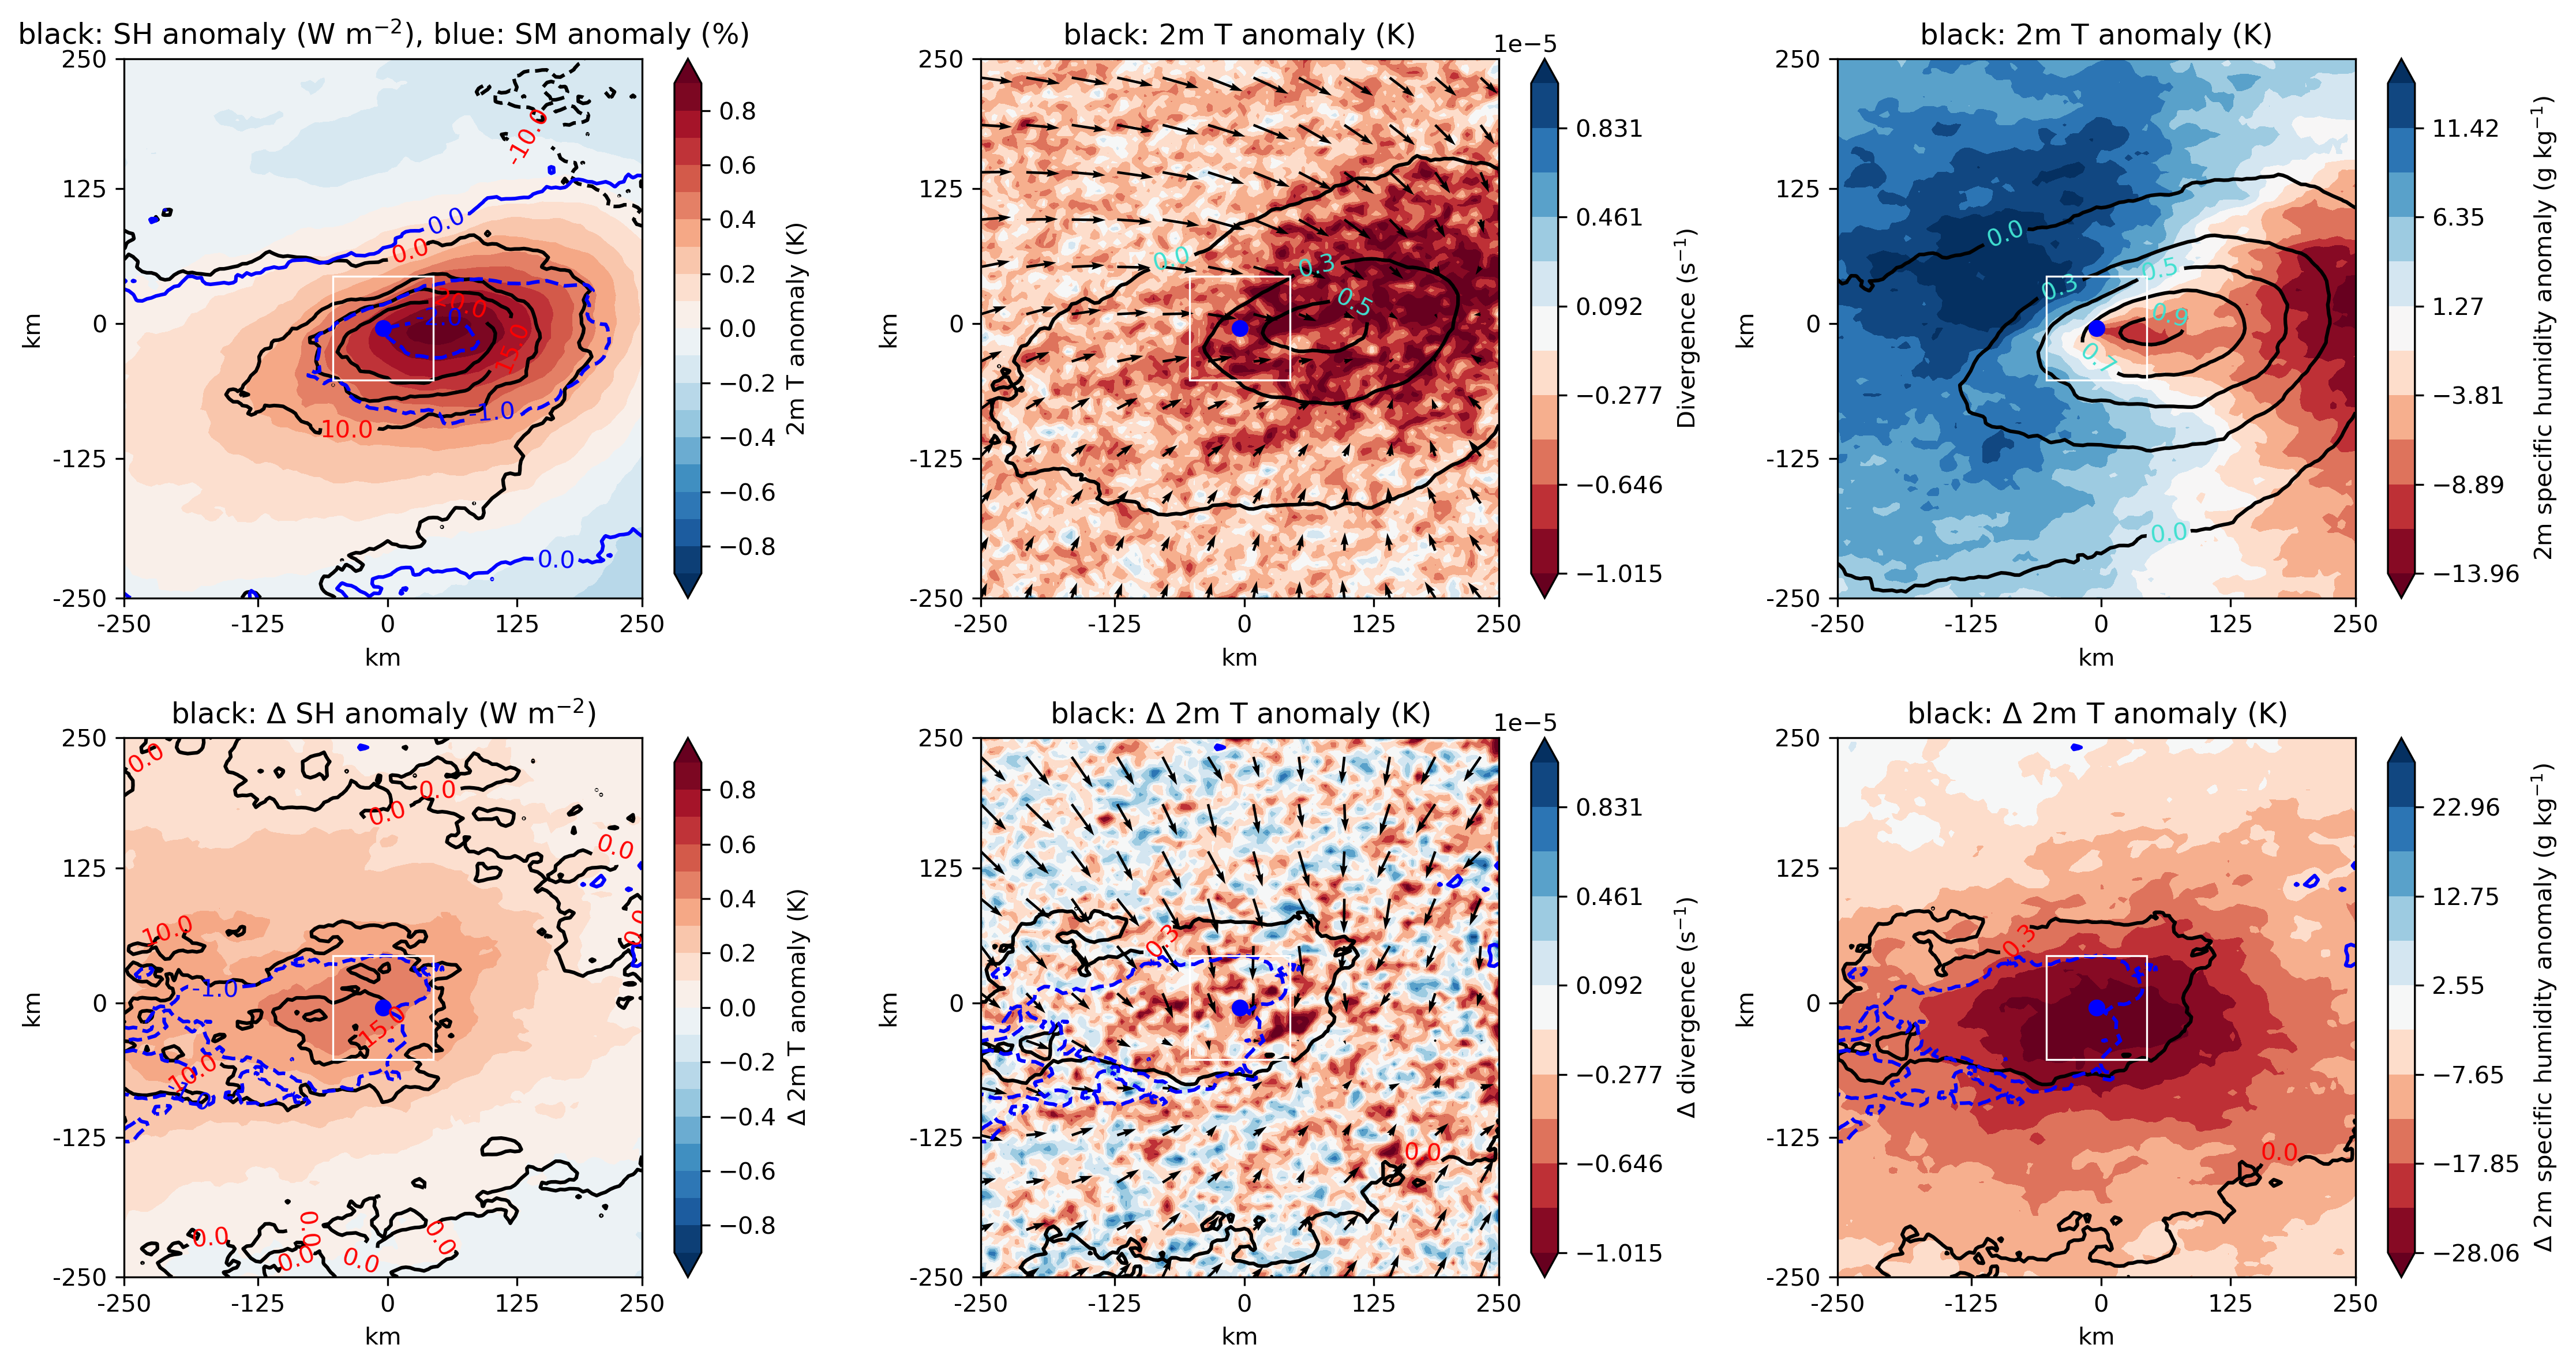

In [43]:
f = plt.figure(figsize=(15,8), dpi=300)
mname = 'node'
extent = 57 #* 4.4

ticks = np.array([0,58-57/2,58,58+57/2,114])
#labels = np.rint([-57*4.4,-57/2*4.4,0,57/2*4.4, 57*4.4])
labels = [-250,-125,0,125,250]
mid=57
dist = 11
box = [mid-dist, mid+dist,mid-dist, mid+dist]

ax = f.add_subplot(2,3,1)

#ano = da_hist_anom['t2']#.mean('cases')
cont =da_hist_anom['sh']
cont2 = da_hist_anom['SM']
ano = da_hist_anom['t2']

thresh = np.max(np.abs(np.percentile(ano, [5, 95])))

plt.contourf(ano, cmap='RdBu_r', extend='both', levels=np.arange(-0.9,0.91,0.1)) #levels=np.linspace(thresh * -1, thresh, 10)
plt.colorbar(label='2m T anomaly (K)')
plt.title(r'black: SH anomaly (W m$^{-2}$), blue: SM anomaly (%)')
cm = ax.contour(cont, colors='k', levels=[-20,-15,-10,0,10,15,20], linewidths=1.5)
ax.clabel(cm, inline=True, fontsize=10, fmt='%1.1f', colors='r')

cm = ax.contour(cont2, colors='blue', levels=[-2,-1,0,1,2], linewidths=1.5)
ax.clabel(cm, inline=True, fontsize=10, fmt='%1.1f', colors='blue')
rect2 = patches.Rectangle((box[0],box[2]),box[1]-box[0],box[3]-box[2],linewidth=0.8,edgecolor='w',facecolor='none', zorder=99)
ax.add_patch(rect2)

plt.plot(extent, extent, 'bo')
ax.set_xlabel('km')
ax.set_ylabel('km')
ax.set_xticks(ticks)
ax.set_xticklabels(labels)
ax.set_yticks(ticks)
ax.set_yticklabels(labels)

ax = f.add_subplot(2,3,2)
ano_div = calc_div(da_hist)
cont = da_hist_anom['t_srfc']

thresh = np.max(np.abs(np.percentile(ano_div, [5, 95])))

plt.contourf(ano_div, cmap='RdBu', extend='both', levels=np.linspace(thresh * -1, thresh, 12)) #levels=np.linspace(thresh * -1, thresh, 10)
plt.colorbar(label='Divergence (s$^{-1}$)')
plt.title(r'black: 2m T anomaly (K)')
cm = ax.contour(cont, colors='k', levels=[-0.9, -0.7,-0.5,-0.3,0,0.3,0.5,0.7,0.9], linewidths=1.5)
ax.clabel(cm, inline=True, fontsize=10, fmt='%1.1f', colors='turquoise')
rect2 = patches.Rectangle((box[0],box[2]),box[1]-box[0],box[3]-box[2],linewidth=0.8,edgecolor='w',facecolor='none', zorder=99)
ax.add_patch(rect2)

pv, pw = da_hist_anom['u_srfc'].values, da_hist_anom['v_srfc'].values
qv = plt.quiver(np.arange(da_hist.longitude.shape[0])[::10], np.arange(da_hist.latitude.shape[0])[::10], pv[::10,::10], pw[::10,::10])

plt.plot(extent, extent, 'bo')
ax.set_xlabel('km')
ax.set_ylabel('km')
ax.set_xticks(ticks)
ax.set_xticklabels(labels)
ax.set_yticks(ticks)
ax.set_yticklabels(labels)


ax = f.add_subplot(2,3,3)
ano = da_hist_anom['lh']
cont = da_hist_anom['t2']

thresh = np.max(np.abs(np.percentile(ano, [5, 95])))

plt.contourf(ano, cmap='RdBu', extend='both', levels=np.linspace(thresh * -1, thresh, 12)) #levels=np.linspace(thresh * -1, thresh, 10)
plt.colorbar(label=r'2m specific humidity anomaly (g kg$^{-1}$)')
plt.title(r'black: 2m T anomaly (K)')
cm = ax.contour(cont, colors='k', levels=[-0.9, -0.7,-0.5,-0.3,0,0.3,0.5,0.7,0.9], linewidths=1.5)
ax.clabel(cm, inline=True, fontsize=10, fmt='%1.1f', colors='turquoise')
rect2 = patches.Rectangle((box[0],box[2]),box[1]-box[0],box[3]-box[2],linewidth=0.8,edgecolor='w',facecolor='none', zorder=99)
ax.add_patch(rect2)


plt.plot(extent, extent, 'bo')
ax.set_xlabel('km')
ax.set_ylabel('km')
ax.set_xticks(ticks)
ax.set_xticklabels(labels)
ax.set_yticks(ticks)
ax.set_yticklabels(labels)



###############################################

ax = f.add_subplot(2,3,4)

#ano = da_hist_anom['t2']#.mean('cases')
cont =da_fut_anom['sh']-da_hist_anom['sh']
cont2 = da_fut_anom['SM']-da_hist_anom['SM']

ano = da_fut_anom['t2']-da_hist_anom['t2']

thresh = np.max(np.abs(np.percentile(ano, [5, 95])))

plt.contourf(ano, cmap='RdBu_r', extend='both', levels=np.arange(-0.9,0.91,0.1))  #levels=np.linspace(thresh * -1, thresh, 10)
plt.colorbar(label=r'$\Delta$ 2m T anomaly (K)')
plt.title(r'black: $\Delta$ SH anomaly (W m$^{-2}$)')
cm = ax.contour(cont, colors='k', levels=[-20,-15,-10,0, 10,15,20], linewidths=1.5)
ax.clabel(cm, inline=True, fontsize=10, fmt='%1.1f', colors='r')
cm = ax.contour(cont2, colors='blue', levels=[-2,-1,0,1,2], linewidths=1.5)
ax.clabel(cm, inline=True, fontsize=10, fmt='%1.1f', colors='blue')

rect2 = patches.Rectangle((box[0],box[2]),box[1]-box[0],box[3]-box[2],linewidth=0.8,edgecolor='w',facecolor='none', zorder=99)
ax.add_patch(rect2)


plt.plot(extent, extent, 'bo')
ax.set_xlabel('km')
ax.set_ylabel('km')
ax.set_xticks(ticks)
ax.set_xticklabels(labels)
ax.set_yticks(ticks)
ax.set_yticklabels(labels)


ax = f.add_subplot(2,3,5)

ano = calc_div(da_hist)
anofut = calc_div(da_fut)
ano = anofut-ano
cont = da_fut_anom['t2']-da_hist_anom['t2']

thresh = np.max(np.abs(np.percentile(ano_div, [5, 95])))

plt.contourf(ano, cmap='RdBu', extend='both', levels=np.linspace(thresh * -1, thresh, 12)) #levels=np.linspace(thresh * -1, thresh, 10)
plt.colorbar(label=r'$\Delta$ divergence (s$^{-1}$)')
plt.title(r'black: $\Delta$ 2m T anomaly (K)')
cm = ax.contour(cont, colors='k', levels=[-0.9,-0.7,-0.5,-0.3,0,0.3,0.5,0.7,0.9], linewidths=1.5)
ax.clabel(cm, inline=True, fontsize=10, fmt='%1.1f', colors='r')
cm = ax.contour(cont2, colors='blue', levels=[-2,-1,0,1,2], linewidths=1.5)
rect2 = patches.Rectangle((box[0],box[2]),box[1]-box[0],box[3]-box[2],linewidth=0.8,edgecolor='w',facecolor='none', zorder=99)
ax.add_patch(rect2)

pv, pw = da_fut_anom['u_srfc'].values-da_hist_anom['u_srfc'].values, da_fut_anom['v_srfc'].values-da_hist_anom['v_srfc'].values
qv = plt.quiver(np.arange(da_hist.longitude.shape[0])[::10], np.arange(da_hist.latitude.shape[0])[::10], pv[::10,::10], pw[::10,::10])

plt.plot(extent, extent, 'bo')
ax.set_xlabel('km')
ax.set_ylabel('km')
ax.set_xticks(ticks)
ax.set_xticklabels(labels)
ax.set_yticks(ticks)
ax.set_yticklabels(labels)

# ax = f.add_subplot(2,4,8)
# pano = da_hist_anom['q_srfc']
# ano = da_fut_anom['q_srfc']-da_hist_anom['q_srfc']
# cont = da_fut['v_srfc']

# thresh = np.max(np.abs(np.percentile(pano, [5, 95])))

# plt.contourf(ano, cmap='RdBu', extend='both', levels=np.linspace(thresh * -1, thresh, 12)) #levels=np.linspace(thresh * -1, thresh, 10)
# plt.colorbar(label='$\Delta$ 925 hPa spec. q anomaly (g kg$^{-1}$)')
# plt.title('black: 925hPa v-wind (m s$^{-1}$)')
# cm = ax.contour(cont, colors='k', levels=[-1.4,-1.2,-1, -0.8, -0.6,-0.4,0,0.4,0.6,0.8,1,1.2,1.4], linewidths=1.5)
# ax.clabel(cm, inline=True, fontsize=10, fmt='%1.1f', colors='r')

# plt.plot(extent, extent, 'bo')
# ax.set_xlabel('km')
# ax.set_ylabel('km')
# ax.set_xticks(ticks)
# ax.set_xticklabels(labels)
# ax.set_yticks(ticks)
# ax.set_yticklabels(labels)


ax = f.add_subplot(2,3,6)
ano = (da_fut_anom['lh']-da_hist_anom['lh'])#*1000
cont = da_fut_anom['t2']-da_hist_anom['t2']
pano = (da_fut_anom['lh'])

qthresh = np.max(np.abs(np.percentile(pano, [5, 95])))

plt.contourf(ano, cmap='RdBu', extend='both', levels=np.linspace(qthresh * -1, qthresh, 12)) 
plt.colorbar(label=r'$\Delta$ 2m specific humidity anomaly (g kg$^{-1}$)')
plt.title(r'black: $\Delta$ 2m T anomaly (K)')
cm = ax.contour(cont, colors='k', levels=[-0.9, -0.7,-0.5,-0.3,0,0.3,0.5,0.7,0.9], linewidths=1.5)
ax.clabel(cm, inline=True, fontsize=10, fmt='%1.1f', colors='r')
cm = ax.contour(cont2, colors='blue', levels=[-2,-1,0,1,2], linewidths=1.5)
rect2 = patches.Rectangle((box[0],box[2]),box[1]-box[0],box[3]-box[2],linewidth=0.8,edgecolor='w',facecolor='none', zorder=99)
ax.add_patch(rect2)


plt.plot(extent, extent, 'bo')
ax.set_xlabel('km')
ax.set_ylabel('km')
ax.set_xticks(ticks)
ax.set_xticklabels(labels)
ax.set_yticks(ticks)
ax.set_yticklabels(labels)



plt.tight_layout()

In [60]:
da_hist_anom = (xr.open_dataset(cp4_path + '/CP4_box_JASMIN/mean3h_v2/hist_anom_Jul-Sep_18h_2d.nc') + xr.open_dataset(cp4_path + '/CP4_box_JASMIN/mean3h_v2/hist_anom_Jul-Sep_17h_2d.nc'))/2
da_fut_anom = (xr.open_dataset(cp4_path + '/CP4_box_JASMIN/mean3h_v2/fut_anom_Jul-Sep_18h_2d.nc')+ xr.open_dataset(cp4_path + '/CP4_box_JASMIN/mean3h_v2/fut_anom_Jul-Sep_17h_2d.nc'))/2

In [61]:
da_hist = (xr.open_dataset(cp4_path + '/CP4_box_JASMIN/mean3h_v2/hist_mean_Jul-Sep_18h_2d.nc') + xr.open_dataset(cp4_path + '/CP4_box_JASMIN/mean3h_v2/hist_mean_Jul-Sep_17h_2d.nc'))/2
da_fut = (xr.open_dataset(cp4_path + '/CP4_box_JASMIN/mean3h_v2/fut_mean_Jul-Sep_18h_2d.nc') + xr.open_dataset(cp4_path + '/CP4_box_JASMIN/mean3h_v2/fut_mean_Jul-Sep_17h_2d.nc'))/2

In [62]:
print(list(da_fut_anom.keys()))

['lw_out_PBLtop', 'lsRain', 'tcwv', 'sh', 'lh', 't2', 'q2', 'shear', 'u_mid', 'u_srfc', 'v_mid', 'v_srfc', 'q_mid', 't_mid', 't_srfc', 'q_srfc', 'geoH_srfc', 'lsRain_noon', 'lwout_noon', 'SM', 'lw_net', 'sw_in', 'sw_net', 'u10', 'v10']


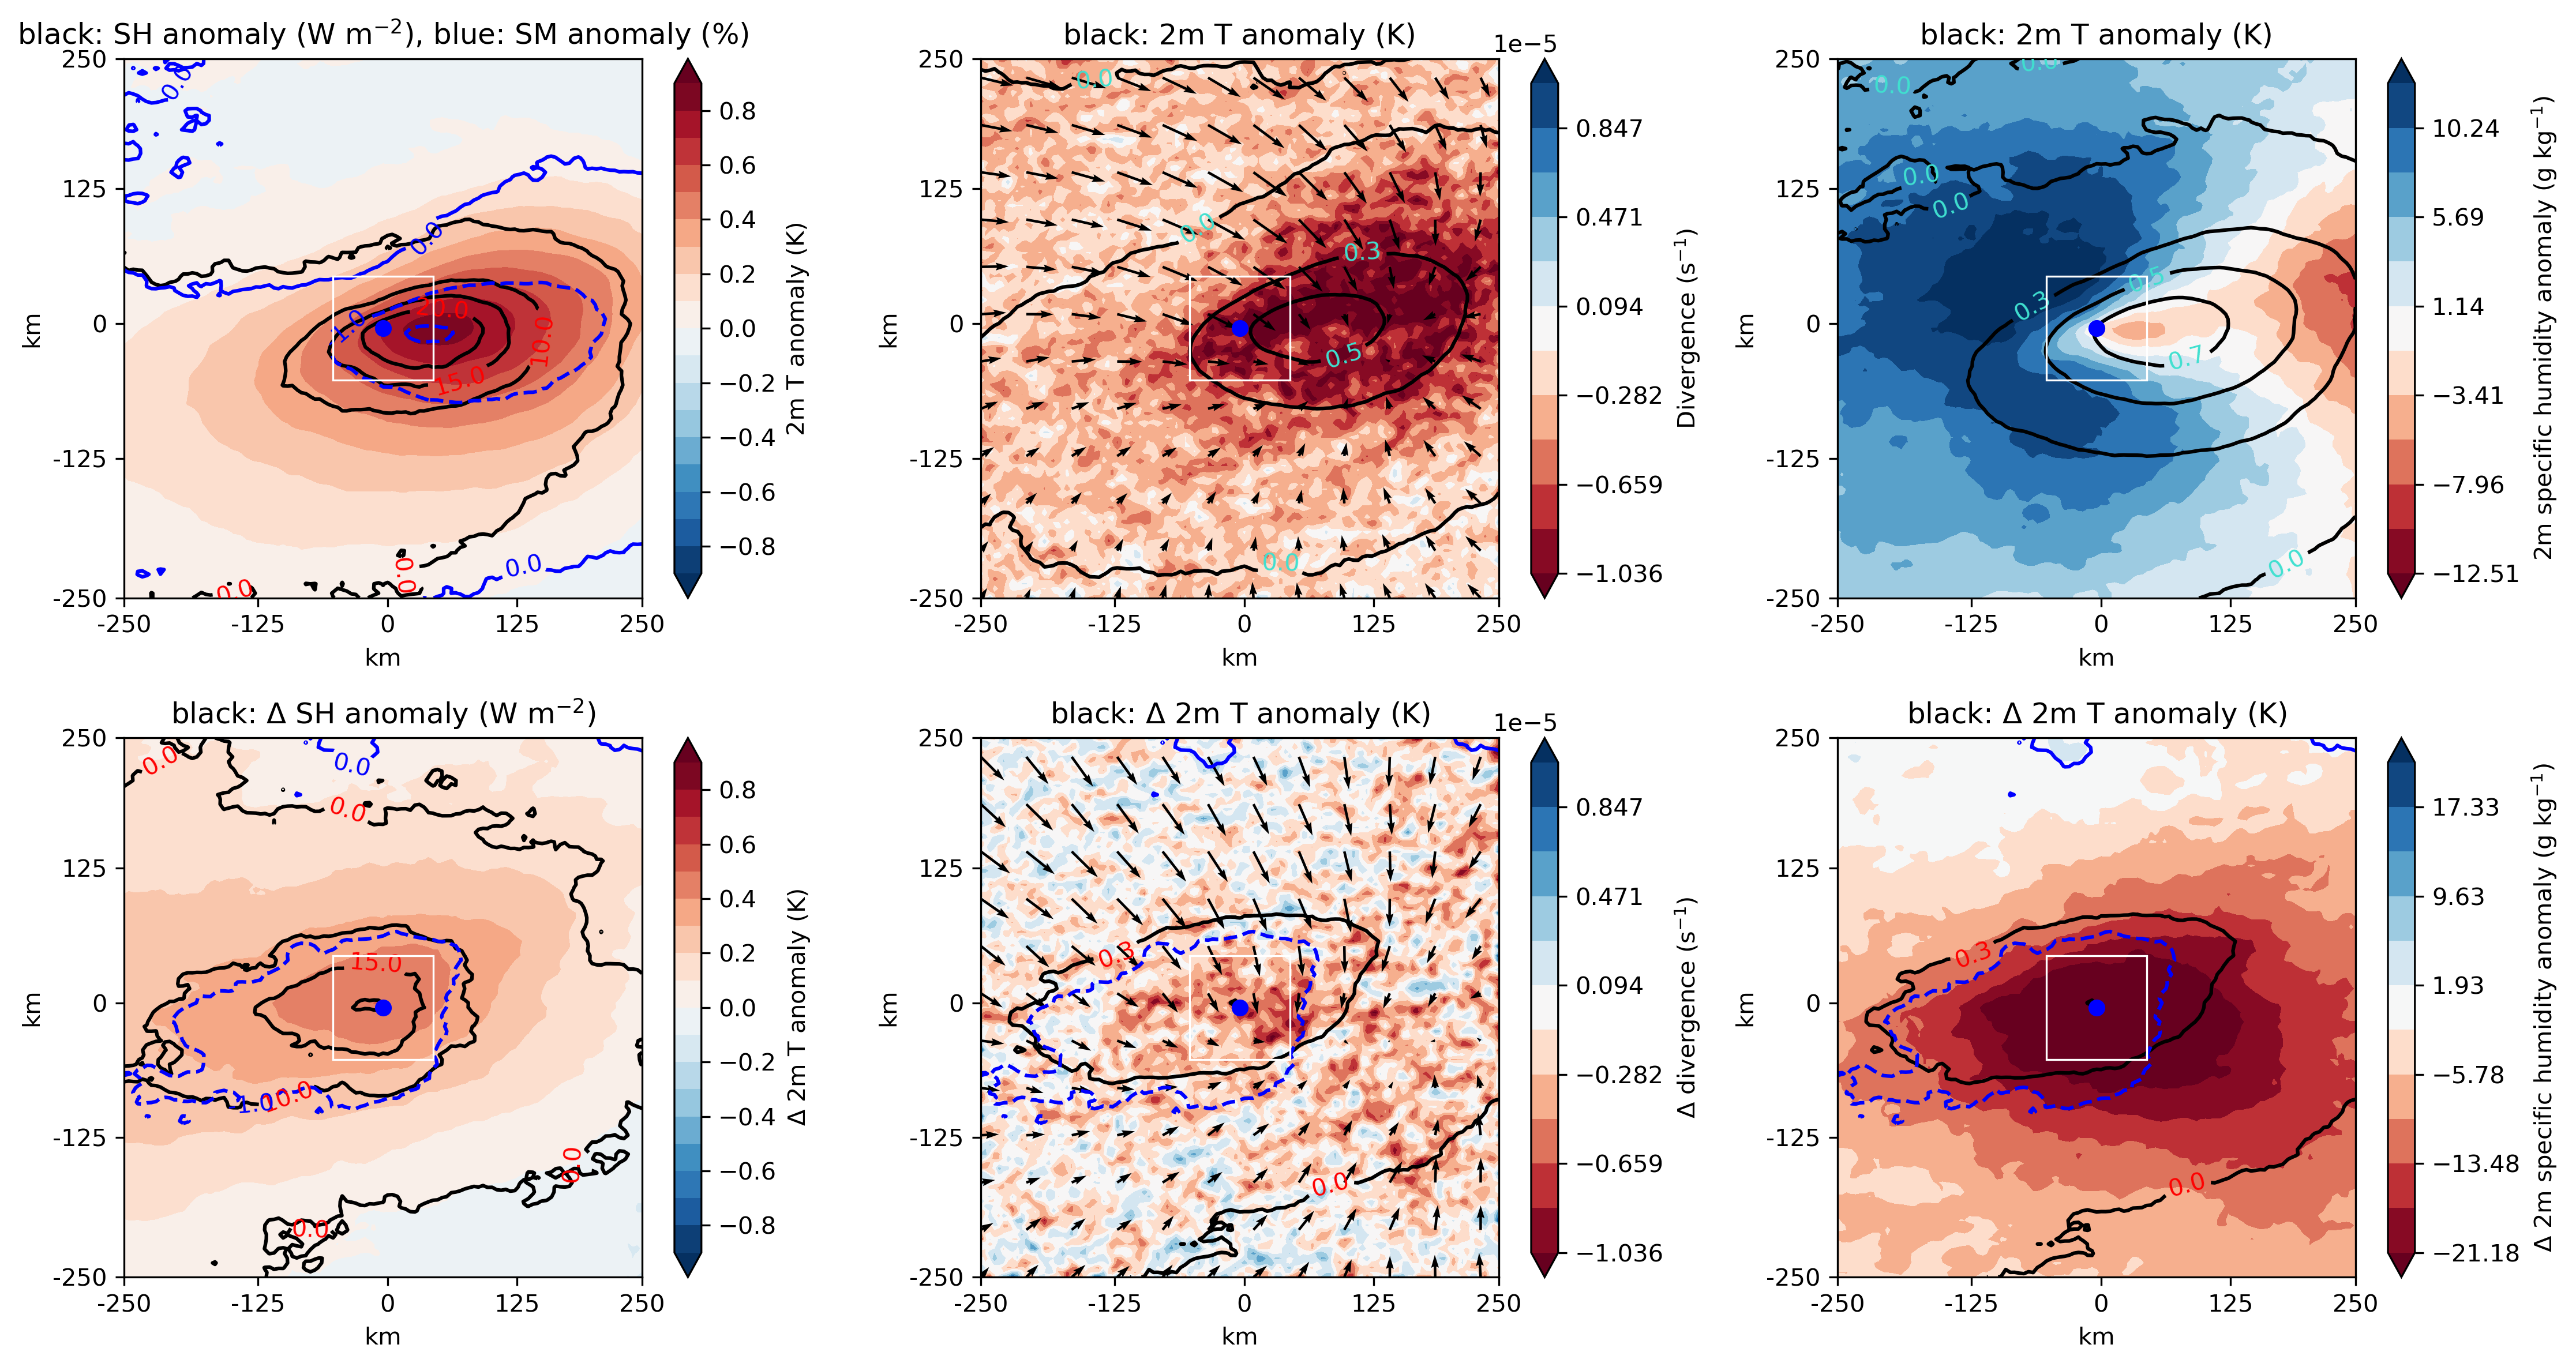

In [63]:
f = plt.figure(figsize=(15,8), dpi=300)
mname = 'node'
extent = 57 #* 4.4

ticks = np.array([0,58-57/2,58,58+57/2,114])
#labels = np.rint([-57*4.4,-57/2*4.4,0,57/2*4.4, 57*4.4])
labels = [-250,-125,0,125,250]
mid=57
dist = 11
box = [mid-dist, mid+dist,mid-dist, mid+dist]

ax = f.add_subplot(2,3,1)

#ano = da_hist_anom['t2']#.mean('cases')
cont =da_hist_anom['sh']
cont2 = da_hist_anom['SM']
ano = da_hist_anom['t2']

thresh = np.max(np.abs(np.percentile(ano, [5, 95])))

plt.contourf(ano, cmap='RdBu_r', extend='both', levels=np.arange(-0.9,0.91,0.1)) #levels=np.linspace(thresh * -1, thresh, 10)
plt.colorbar(label='2m T anomaly (K)')
plt.title(r'black: SH anomaly (W m$^{-2}$), blue: SM anomaly (%)')
cm = ax.contour(cont, colors='k', levels=[-20,-15,-10,0,10,15,20], linewidths=1.5)
ax.clabel(cm, inline=True, fontsize=10, fmt='%1.1f', colors='r')

cm = ax.contour(cont2, colors='blue', levels=[-2,-1,0,1,2], linewidths=1.5)
ax.clabel(cm, inline=True, fontsize=10, fmt='%1.1f', colors='blue')
rect2 = patches.Rectangle((box[0],box[2]),box[1]-box[0],box[3]-box[2],linewidth=0.8,edgecolor='w',facecolor='none', zorder=99)
ax.add_patch(rect2)

plt.plot(extent, extent, 'bo')
ax.set_xlabel('km')
ax.set_ylabel('km')
ax.set_xticks(ticks)
ax.set_xticklabels(labels)
ax.set_yticks(ticks)
ax.set_yticklabels(labels)

ax = f.add_subplot(2,3,2)
ano_div = calc_div(da_hist)
cont = da_hist_anom['t_srfc']

thresh = np.max(np.abs(np.percentile(ano_div, [5, 95])))

plt.contourf(ano_div, cmap='RdBu', extend='both', levels=np.linspace(thresh * -1, thresh, 12)) #levels=np.linspace(thresh * -1, thresh, 10)
plt.colorbar(label='Divergence (s$^{-1}$)')
plt.title(r'black: 2m T anomaly (K)')
cm = ax.contour(cont, colors='k', levels=[-0.9, -0.7,-0.5,-0.3,0,0.3,0.5,0.7,0.9], linewidths=1.5)
ax.clabel(cm, inline=True, fontsize=10, fmt='%1.1f', colors='turquoise')
rect2 = patches.Rectangle((box[0],box[2]),box[1]-box[0],box[3]-box[2],linewidth=0.8,edgecolor='w',facecolor='none', zorder=99)
ax.add_patch(rect2)

pv, pw = da_hist_anom['u_srfc'].values, da_hist_anom['v_srfc'].values
qv = plt.quiver(np.arange(da_hist.longitude.shape[0])[::10], np.arange(da_hist.latitude.shape[0])[::10], pv[::10,::10], pw[::10,::10])

plt.plot(extent, extent, 'bo')
ax.set_xlabel('km')
ax.set_ylabel('km')
ax.set_xticks(ticks)
ax.set_xticklabels(labels)
ax.set_yticks(ticks)
ax.set_yticklabels(labels)


ax = f.add_subplot(2,3,3)
ano = da_hist_anom['lh']
cont = da_hist_anom['t2']

thresh = np.max(np.abs(np.percentile(ano, [5, 95])))

plt.contourf(ano, cmap='RdBu', extend='both', levels=np.linspace(thresh * -1, thresh, 12)) #levels=np.linspace(thresh * -1, thresh, 10)
plt.colorbar(label=r'2m specific humidity anomaly (g kg$^{-1}$)')
plt.title(r'black: 2m T anomaly (K)')
cm = ax.contour(cont, colors='k', levels=[-0.9, -0.7,-0.5,-0.3,0,0.3,0.5,0.7,0.9], linewidths=1.5)
ax.clabel(cm, inline=True, fontsize=10, fmt='%1.1f', colors='turquoise')
rect2 = patches.Rectangle((box[0],box[2]),box[1]-box[0],box[3]-box[2],linewidth=0.8,edgecolor='w',facecolor='none', zorder=99)
ax.add_patch(rect2)


plt.plot(extent, extent, 'bo')
ax.set_xlabel('km')
ax.set_ylabel('km')
ax.set_xticks(ticks)
ax.set_xticklabels(labels)
ax.set_yticks(ticks)
ax.set_yticklabels(labels)



###############################################

ax = f.add_subplot(2,3,4)

#ano = da_hist_anom['t2']#.mean('cases')
cont =da_fut_anom['sh']-da_hist_anom['sh']
cont2 = da_fut_anom['SM']-da_hist_anom['SM']

ano = da_fut_anom['t2']-da_hist_anom['t2']

thresh = np.max(np.abs(np.percentile(ano, [5, 95])))

plt.contourf(ano, cmap='RdBu_r', extend='both', levels=np.arange(-0.9,0.91,0.1))  #levels=np.linspace(thresh * -1, thresh, 10)
plt.colorbar(label=r'$\Delta$ 2m T anomaly (K)')
plt.title(r'black: $\Delta$ SH anomaly (W m$^{-2}$)')
cm = ax.contour(cont, colors='k', levels=[-20,-15,-10,0, 10,15,20], linewidths=1.5)
ax.clabel(cm, inline=True, fontsize=10, fmt='%1.1f', colors='r')
cm = ax.contour(cont2, colors='blue', levels=[-2,-1,0,1,2], linewidths=1.5)
ax.clabel(cm, inline=True, fontsize=10, fmt='%1.1f', colors='blue')

rect2 = patches.Rectangle((box[0],box[2]),box[1]-box[0],box[3]-box[2],linewidth=0.8,edgecolor='w',facecolor='none', zorder=99)
ax.add_patch(rect2)


plt.plot(extent, extent, 'bo')
ax.set_xlabel('km')
ax.set_ylabel('km')
ax.set_xticks(ticks)
ax.set_xticklabels(labels)
ax.set_yticks(ticks)
ax.set_yticklabels(labels)


ax = f.add_subplot(2,3,5)

ano = calc_div(da_hist)
anofut = calc_div(da_fut)
ano = anofut-ano
cont = da_fut_anom['t2']-da_hist_anom['t2']

thresh = np.max(np.abs(np.percentile(ano_div, [5, 95])))

plt.contourf(ano, cmap='RdBu', extend='both', levels=np.linspace(thresh * -1, thresh, 12)) #levels=np.linspace(thresh * -1, thresh, 10)
plt.colorbar(label=r'$\Delta$ divergence (s$^{-1}$)')
plt.title(r'black: $\Delta$ 2m T anomaly (K)')
cm = ax.contour(cont, colors='k', levels=[-0.9,-0.7,-0.5,-0.3,0,0.3,0.5,0.7,0.9], linewidths=1.5)
ax.clabel(cm, inline=True, fontsize=10, fmt='%1.1f', colors='r')
cm = ax.contour(cont2, colors='blue', levels=[-2,-1,0,1,2], linewidths=1.5)
rect2 = patches.Rectangle((box[0],box[2]),box[1]-box[0],box[3]-box[2],linewidth=0.8,edgecolor='w',facecolor='none', zorder=99)
ax.add_patch(rect2)

pv, pw = da_fut_anom['u_srfc'].values-da_hist_anom['u_srfc'].values, da_fut_anom['v_srfc'].values-da_hist_anom['v_srfc'].values
qv = plt.quiver(np.arange(da_hist.longitude.shape[0])[::10], np.arange(da_hist.latitude.shape[0])[::10], pv[::10,::10], pw[::10,::10])

plt.plot(extent, extent, 'bo')
ax.set_xlabel('km')
ax.set_ylabel('km')
ax.set_xticks(ticks)
ax.set_xticklabels(labels)
ax.set_yticks(ticks)
ax.set_yticklabels(labels)

# ax = f.add_subplot(2,4,8)
# pano = da_hist_anom['q_srfc']
# ano = da_fut_anom['q_srfc']-da_hist_anom['q_srfc']
# cont = da_fut['v_srfc']

# thresh = np.max(np.abs(np.percentile(pano, [5, 95])))

# plt.contourf(ano, cmap='RdBu', extend='both', levels=np.linspace(thresh * -1, thresh, 12)) #levels=np.linspace(thresh * -1, thresh, 10)
# plt.colorbar(label='$\Delta$ 925 hPa spec. q anomaly (g kg$^{-1}$)')
# plt.title('black: 925hPa v-wind (m s$^{-1}$)')
# cm = ax.contour(cont, colors='k', levels=[-1.4,-1.2,-1, -0.8, -0.6,-0.4,0,0.4,0.6,0.8,1,1.2,1.4], linewidths=1.5)
# ax.clabel(cm, inline=True, fontsize=10, fmt='%1.1f', colors='r')

# plt.plot(extent, extent, 'bo')
# ax.set_xlabel('km')
# ax.set_ylabel('km')
# ax.set_xticks(ticks)
# ax.set_xticklabels(labels)
# ax.set_yticks(ticks)
# ax.set_yticklabels(labels)


ax = f.add_subplot(2,3,6)
ano = (da_fut_anom['lh']-da_hist_anom['lh'])#*1000
cont = da_fut_anom['t2']-da_hist_anom['t2']
pano = (da_fut_anom['lh'])

qthresh = np.max(np.abs(np.percentile(pano, [5, 95])))

plt.contourf(ano, cmap='RdBu', extend='both', levels=np.linspace(qthresh * -1, qthresh, 12)) 
plt.colorbar(label=r'$\Delta$ 2m specific humidity anomaly (g kg$^{-1}$)')
plt.title(r'black: $\Delta$ 2m T anomaly (K)')
cm = ax.contour(cont, colors='k', levels=[-0.9, -0.7,-0.5,-0.3,0,0.3,0.5,0.7,0.9], linewidths=1.5)
ax.clabel(cm, inline=True, fontsize=10, fmt='%1.1f', colors='r')
cm = ax.contour(cont2, colors='blue', levels=[-2,-1,0,1,2], linewidths=1.5)
rect2 = patches.Rectangle((box[0],box[2]),box[1]-box[0],box[3]-box[2],linewidth=0.8,edgecolor='w',facecolor='none', zorder=99)
ax.add_patch(rect2)


plt.plot(extent, extent, 'bo')
ax.set_xlabel('km')
ax.set_ylabel('km')
ax.set_xticks(ticks)
ax.set_xticklabels(labels)
ax.set_yticks(ticks)
ax.set_yticklabels(labels)



plt.tight_layout()

In [ ]:
da_hist_anom = xr.open_dataset(cp4_path + '/CP4_box_JASMIN/mean3h_v2/hist_anom_Jul-Sep_18h_2d.nc') #+ xr.open_dataset(cp4_path + '/CP4_box_JASMIN/mean3h_v2/hist_anom_all_18h_2d.nc')
da_fut_anom = xr.open_dataset(cp4_path + '/CP4_box_JASMIN/mean3h_v2/fut_anom_Jul-Sep_18h_2d.nc')

In [ ]:
f = plt.figure(figsize=(15,8), dpi=300)
mname = 'node'
extent = 57 #* 4.4

ticks = np.array([0,58-57/2,58,58+57/2,114])
#labels = np.rint([-57*4.4,-57/2*4.4,0,57/2*4.4, 57*4.4])
labels = [-250,-125,0,125,250]
mid=57
dist = 11
box = [mid-dist, mid+dist,mid-dist, mid+dist]

ax = f.add_subplot(2,3,1)

#ano = da_hist_anom['t2']#.mean('cases')
cont =da_hist_anom['sh']
cont2 = da_hist_anom['SM']
ano = da_hist_anom['t2']

thresh = np.max(np.abs(np.percentile(ano, [5, 95])))

plt.contourf(ano, cmap='RdBu_r', extend='both', levels=np.arange(-0.9,0.91,0.1)) #levels=np.linspace(thresh * -1, thresh, 10)
plt.colorbar(label='2m T anomaly (K)')
plt.title(r'black: SH anomaly (W m$^{-2}$), blue: SM anomaly (%)')
cm = ax.contour(cont, colors='k', levels=[-20,-15,-10,0,10,15,20], linewidths=1.5)
ax.clabel(cm, inline=True, fontsize=10, fmt='%1.1f', colors='r')

cm = ax.contour(cont2, colors='blue', levels=[-2,-1,0,1,2], linewidths=1.5)
ax.clabel(cm, inline=True, fontsize=10, fmt='%1.1f', colors='blue')
rect2 = patches.Rectangle((box[0],box[2]),box[1]-box[0],box[3]-box[2],linewidth=0.8,edgecolor='w',facecolor='none', zorder=99)
ax.add_patch(rect2)

plt.plot(extent, extent, 'bo')
ax.set_xlabel('km')
ax.set_ylabel('km')
ax.set_xticks(ticks)
ax.set_xticklabels(labels)
ax.set_yticks(ticks)
ax.set_yticklabels(labels)

ax = f.add_subplot(2,3,2)
ano_div = calc_div(da_hist)
cont = da_hist_anom['t_srfc']

thresh = np.max(np.abs(np.percentile(ano_div, [5, 95])))

plt.contourf(ano_div, cmap='RdBu', extend='both', levels=np.linspace(thresh * -1, thresh, 12)) #levels=np.linspace(thresh * -1, thresh, 10)
plt.colorbar(label='Divergence (s$^{-1}$)')
plt.title(r'black: 2m T anomaly (K)')
cm = ax.contour(cont, colors='k', levels=[-0.9, -0.7,-0.5,-0.3,0,0.3,0.5,0.7,0.9], linewidths=1.5)
ax.clabel(cm, inline=True, fontsize=10, fmt='%1.1f', colors='turquoise')
rect2 = patches.Rectangle((box[0],box[2]),box[1]-box[0],box[3]-box[2],linewidth=0.8,edgecolor='w',facecolor='none', zorder=99)
ax.add_patch(rect2)

pv, pw = da_hist_anom['u_srfc'].values, da_hist_anom['v_srfc'].values
qv = plt.quiver(np.arange(da_hist.longitude.shape[0])[::10], np.arange(da_hist.latitude.shape[0])[::10], pv[::10,::10], pw[::10,::10])

plt.plot(extent, extent, 'bo')
ax.set_xlabel('km')
ax.set_ylabel('km')
ax.set_xticks(ticks)
ax.set_xticklabels(labels)
ax.set_yticks(ticks)
ax.set_yticklabels(labels)


ax = f.add_subplot(2,3,3)
ano = da_hist_anom['lh']
cont = da_hist_anom['t2']

thresh = np.max(np.abs(np.percentile(ano, [5, 95])))

plt.contourf(ano, cmap='RdBu', extend='both', levels=np.linspace(thresh * -1, thresh, 12)) #levels=np.linspace(thresh * -1, thresh, 10)
plt.colorbar(label=r'2m specific humidity anomaly (g kg$^{-1}$)')
plt.title(r'black: 2m T anomaly (K)')
cm = ax.contour(cont, colors='k', levels=[-0.9, -0.7,-0.5,-0.3,0,0.3,0.5,0.7,0.9], linewidths=1.5)
ax.clabel(cm, inline=True, fontsize=10, fmt='%1.1f', colors='turquoise')
rect2 = patches.Rectangle((box[0],box[2]),box[1]-box[0],box[3]-box[2],linewidth=0.8,edgecolor='w',facecolor='none', zorder=99)
ax.add_patch(rect2)


plt.plot(extent, extent, 'bo')
ax.set_xlabel('km')
ax.set_ylabel('km')
ax.set_xticks(ticks)
ax.set_xticklabels(labels)
ax.set_yticks(ticks)
ax.set_yticklabels(labels)



###############################################

ax = f.add_subplot(2,3,4)

#ano = da_hist_anom['t2']#.mean('cases')
cont =da_fut_anom['sh']-da_hist_anom['sh']
cont2 = da_fut_anom['SM']-da_hist_anom['SM']

ano = da_fut_anom['t2']-da_hist_anom['t2']

thresh = np.max(np.abs(np.percentile(ano, [5, 95])))

plt.contourf(ano, cmap='RdBu_r', extend='both', levels=np.arange(-0.9,0.91,0.1))  #levels=np.linspace(thresh * -1, thresh, 10)
plt.colorbar(label=r'$\Delta$ 2m T anomaly (K)')
plt.title(r'black: $\Delta$ SH anomaly (W m$^{-2}$)')
cm = ax.contour(cont, colors='k', levels=[-20,-15,-10,0, 10,15,20], linewidths=1.5)
ax.clabel(cm, inline=True, fontsize=10, fmt='%1.1f', colors='r')
cm = ax.contour(cont2, colors='blue', levels=[-2,-1,0,1,2], linewidths=1.5)
ax.clabel(cm, inline=True, fontsize=10, fmt='%1.1f', colors='blue')

rect2 = patches.Rectangle((box[0],box[2]),box[1]-box[0],box[3]-box[2],linewidth=0.8,edgecolor='w',facecolor='none', zorder=99)
ax.add_patch(rect2)


plt.plot(extent, extent, 'bo')
ax.set_xlabel('km')
ax.set_ylabel('km')
ax.set_xticks(ticks)
ax.set_xticklabels(labels)
ax.set_yticks(ticks)
ax.set_yticklabels(labels)


ax = f.add_subplot(2,3,5)

ano = calc_div(da_hist)
anofut = calc_div(da_fut)
ano = anofut-ano
cont = da_fut_anom['t2']-da_hist_anom['t2']

thresh = np.max(np.abs(np.percentile(ano_div, [5, 95])))

plt.contourf(ano, cmap='RdBu', extend='both', levels=np.linspace(thresh * -1, thresh, 12)) #levels=np.linspace(thresh * -1, thresh, 10)
plt.colorbar(label=r'$\Delta$ divergence (s$^{-1}$)')
plt.title(r'black: $\Delta$ 2m T anomaly (K)')
cm = ax.contour(cont, colors='k', levels=[-0.9,-0.7,-0.5,-0.3,0,0.3,0.5,0.7,0.9], linewidths=1.5)
ax.clabel(cm, inline=True, fontsize=10, fmt='%1.1f', colors='r')
cm = ax.contour(cont2, colors='blue', levels=[-2,-1,0,1,2], linewidths=1.5)
rect2 = patches.Rectangle((box[0],box[2]),box[1]-box[0],box[3]-box[2],linewidth=0.8,edgecolor='w',facecolor='none', zorder=99)
ax.add_patch(rect2)

pv, pw = da_fut_anom['u_srfc'].values-da_hist_anom['u_srfc'].values, da_fut_anom['v_srfc'].values-da_hist_anom['v_srfc'].values
qv = plt.quiver(np.arange(da_hist.longitude.shape[0])[::10], np.arange(da_hist.latitude.shape[0])[::10], pv[::10,::10], pw[::10,::10])

plt.plot(extent, extent, 'bo')
ax.set_xlabel('km')
ax.set_ylabel('km')
ax.set_xticks(ticks)
ax.set_xticklabels(labels)
ax.set_yticks(ticks)
ax.set_yticklabels(labels)

# ax = f.add_subplot(2,4,8)
# pano = da_hist_anom['q_srfc']
# ano = da_fut_anom['q_srfc']-da_hist_anom['q_srfc']
# cont = da_fut['v_srfc']

# thresh = np.max(np.abs(np.percentile(pano, [5, 95])))

# plt.contourf(ano, cmap='RdBu', extend='both', levels=np.linspace(thresh * -1, thresh, 12)) #levels=np.linspace(thresh * -1, thresh, 10)
# plt.colorbar(label='$\Delta$ 925 hPa spec. q anomaly (g kg$^{-1}$)')
# plt.title('black: 925hPa v-wind (m s$^{-1}$)')
# cm = ax.contour(cont, colors='k', levels=[-1.4,-1.2,-1, -0.8, -0.6,-0.4,0,0.4,0.6,0.8,1,1.2,1.4], linewidths=1.5)
# ax.clabel(cm, inline=True, fontsize=10, fmt='%1.1f', colors='r')

# plt.plot(extent, extent, 'bo')
# ax.set_xlabel('km')
# ax.set_ylabel('km')
# ax.set_xticks(ticks)
# ax.set_xticklabels(labels)
# ax.set_yticks(ticks)
# ax.set_yticklabels(labels)


ax = f.add_subplot(2,3,6)
ano = (da_fut_anom['sw_in']-da_hist_anom['sw_in'])#*1000
cont = da_fut_anom['t2']-da_hist_anom['t2']
pano = (da_fut_anom['sw_in'])

qthresh = np.max(np.abs(np.percentile(pano, [5, 95])))

plt.contourf(ano, cmap='RdBu', extend='both', levels=np.linspace(qthresh * -1, qthresh, 12)) 
plt.colorbar(label=r'$\Delta$ 2m specific humidity anomaly (g kg$^{-1}$)')
plt.title(r'black: $\Delta$ 2m T anomaly (K)')
cm = ax.contour(cont, colors='k', levels=[-0.9, -0.7,-0.5,-0.3,0,0.3,0.5,0.7,0.9], linewidths=1.5)
ax.clabel(cm, inline=True, fontsize=10, fmt='%1.1f', colors='r')
cm = ax.contour(cont2, colors='blue', levels=[-2,-1,0,1,2], linewidths=1.5)
rect2 = patches.Rectangle((box[0],box[2]),box[1]-box[0],box[3]-box[2],linewidth=0.8,edgecolor='w',facecolor='none', zorder=99)
ax.add_patch(rect2)


plt.plot(extent, extent, 'bo')
ax.set_xlabel('km')
ax.set_ylabel('km')
ax.set_xticks(ticks)
ax.set_xticklabels(labels)
ax.set_yticks(ticks)
ax.set_yticklabels(labels)



plt.tight_layout()